# Libraries

In [158]:
import contractions
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import textwrap
from itertools import islice
from statsmodels.multivariate.manova import MANOVA
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm
tqdm.pandas()

# Read Data

## Lexicon

In [55]:
# run if the expanded lexicon file is not available
vad_lexicon = pd.read_csv('./data/vad/NRC-VAD-Lexicon-v2.1-edited.txt', sep='\t', header=0, keep_default_na=False, na_values=[])


### 5-gram lexicons

In [56]:
# filter only 5-grams lexicons
five_grams_lexicon = vad_lexicon[vad_lexicon['term'].str.split().str.len() == 5].copy()

### 4-gram lexicons

In [57]:
# filter only 4-grams lexicons
four_grams_lexicon = vad_lexicon[vad_lexicon['term'].str.split().str.len() == 4].copy()

### 3-gram lexicons

In [58]:
# filter only 3-grams lexicons
three_grams_lexicon = vad_lexicon[vad_lexicon['term'].str.split().str.len() == 3].copy()

### 2-gram lexicons

In [59]:
# filter only 2-grams lexicons
two_grams_lexicon = vad_lexicon[vad_lexicon['term'].str.split().str.len() == 2].copy()

### 1-gram lexicons

In [60]:
# filter only 1-gram lexicons
one_gram_lexicon = vad_lexicon[vad_lexicon['term'].str.split().str.len() == 1].copy()

## Post - Last Comment Data

In [70]:
post_last_comment_table_max14days = pd.read_csv('./data/BeyondBlue/commented_post_authors_max14days_2.csv', header=0)

In [71]:
post_last_comment_table_max14days.head()

,Post_ID,Author,Author_Post,Author_Last_Comment,Num_Post_Author_Comments,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,Moderator,Valued Contributor,Days_Between
0,Anxi-6,Amenace,"Parental Anxiety. Hi Everyone, I'm not quite s...",Thank you Indigo. I am seeing a counsellor ton...,1,0,0,0,1,0,0,0,0
1,Anxi-12,Whatsinaname,"Horrible week. Hi everyone, I'm having a horri...","Hi Petal, Thanks again for posting, your posit...",16,0,2,12,0,0,0,0,9
2,Anxi-13,Sammy,New relationship anxiety. Dear AllJust need a ...,Thanks Rangayes I told him and he apologised a...,2,0,0,0,0,2,0,0,1
3,Anxi-17,Olive83,Easy strategies for quick response. Recently m...,You're not wrong Caught between! And I did exa...,4,0,0,0,1,4,0,1,8
4,Anxi-34,Gobble,Any idea?. I need a little help. On a generali...,She then spread rumurs horrid things that coul...,2,0,0,0,2,0,0,0,2


# Feature Engineering/Extraction

## Check the Maximum N-gram in 'term'

In [63]:
# check the maximum n-gram in 'term'
max(vad_lexicon['term'].apply(lambda x: len(x.split(' '))))

5

## `vad()`

measures the VAD of post and reply

In [73]:
POLAR_THRESH = 0.333  # abs(value) >= threshold is considered polar

def _build_index(df):
    """
    Convert a lexicon DataFrame to a dict: term -> (valence, arousal, dominance).
    Assumes columns: ['term','valence','arousal','dominance'].
    """
    # normalize once to lowercase to match tokenization step
    # if your 'term' is already lowercase, this is still harmless
    return {str(t).lower(): (str(t).lower(), float(v), float(a), float(d))
            for t, v, a, d in zip(df['term'], df['valence'], df['arousal'], df['dominance'])}

def vad(
    text,
    five_grams_lexicon=five_grams_lexicon,
    four_grams_lexicon=four_grams_lexicon,
    three_grams_lexicon=three_grams_lexicon,
    two_grams_lexicon=two_grams_lexicon,
    one_gram_lexicon=one_gram_lexicon,
    polar_subset=False,
    tokenizer=word_tokenize,
):
    """
    Compute average VAD with longest-match wins across 5→1 grams.
    If polar_subset=True, only include a dimension's score when that dimension is polar for the term.
    """
    # 1) Tokenize once
    words = tokenizer(text.lower())

    # 2) Build fast lookup dicts once (O(n) upfront, O(1) per lookup after)
    idx = {
        5: _build_index(five_grams_lexicon),
        4: _build_index(four_grams_lexicon),
        3: _build_index(three_grams_lexicon),
        2: _build_index(two_grams_lexicon),
        1: _build_index(one_gram_lexicon),
    }

    valence_scores, arousal_scores, dominance_scores = [], [], []
    matched_ngrams, matched_ngrams_valence, matched_ngrams_arousal, matched_ngrams_dominance = [], [], [], []
    if polar_subset:
        matched_positions_valence = set()
        matched_positions_arousal = set()
        matched_positions_dominance = set()
    else:
        matched_positions = set()

    # 3) Sweep n-grams from longest to shortest
    N = len(words)
    for n in (5, 4, 3, 2, 1):
        if N < n:
            continue
        lex = idx[n]
        if polar_subset:
            n_gram_matched_positions_valence = set()
            n_gram_matched_positions_arousal = set()
            n_gram_matched_positions_dominance = set()
        else:
            n_gram_matched_positions = set()
        # slide a window of length n
        for start in range(0, N - n + 1):
            span = range(start, start + n)
            # skip if any token already consumed by a longer match
            if (not polar_subset) and matched_positions.intersection(span):
                continue
            term = ' '.join(words[start:start + n])
            triplet = lex.get(term)
            if triplet is not None:
                t, v, a, d = triplet
                if not polar_subset:
                    valence_scores.append(v)
                    arousal_scores.append(a)
                    dominance_scores.append(d)
                    matched_ngrams.append(t)
                    n_gram_matched_positions.update(span)
                else:
                    if abs(v) >= POLAR_THRESH:
                        if matched_positions_valence.intersection(span):
                            continue  # Skip if any word in the n-gram is part of a matched n-gram
                        valence_scores.append(v)
                        matched_ngrams_valence.append(t)
                        n_gram_matched_positions_valence.update(span)
                    if abs(a) >= POLAR_THRESH:
                        if matched_positions_arousal.intersection(span):
                            continue  # Skip if any word in the n-gram is part of a matched n-gram
                        arousal_scores.append(a)
                        matched_ngrams_arousal.append(t)
                        n_gram_matched_positions_arousal.update(span)
                    if abs(d) >= POLAR_THRESH:
                        if matched_positions_dominance.intersection(span):
                            continue  # Skip if any word in the n-gram is part of a matched n-gram
                        dominance_scores.append(d)
                        matched_ngrams_dominance.append(t)
                        n_gram_matched_positions_dominance.update(span)
        # update matched positions
        if polar_subset:
            matched_positions_valence.update(n_gram_matched_positions_valence)
            matched_positions_arousal.update(n_gram_matched_positions_arousal)
            matched_positions_dominance.update(n_gram_matched_positions_dominance)
        else:
            matched_positions.update(n_gram_matched_positions)

    # 4) Averages (None if empty)
    avg_valence   = (sum(valence_scores) / len(valence_scores)) if valence_scores else None
    avg_arousal   = (sum(arousal_scores) / len(arousal_scores)) if arousal_scores else None
    avg_dominance = (sum(dominance_scores) / len(dominance_scores)) if dominance_scores else None

    return {
        'valence': avg_valence,
        'arousal': avg_arousal,
        'dominance': avg_dominance,
    }
    # return matched_ngrams_valence, valence_scores

## Add VAD Scores and Diffs to Post - Last Comment table 

In [74]:
vad_table = post_last_comment_table_max14days.copy()
# add VAD scores to mental_health_severity_table
vad_table[['Post_Valence', 'Post_Arousal', 'Post_Dominance']] = vad_table['Author_Post'].progress_apply(lambda x: pd.Series(vad(x)))
vad_table[['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']] = vad_table['Author_Last_Comment'].progress_apply(lambda x: pd.Series(vad(x)))
# add VAD scores diff between post and comment
vad_table['Valence_Diff'] = vad_table['Comment_Valence'] - vad_table['Post_Valence']
vad_table['Arousal_Diff'] = vad_table['Comment_Arousal'] - vad_table['Post_Arousal']
vad_table['Dominance_Diff'] = vad_table['Comment_Dominance'] - vad_table['Post_Dominance']
vad_table.head()

100%|██████████| 8387/8387 [10:47<00:00, 12.95it/s]


,Post_ID,Author,Author_Post,Author_Last_Comment,Num_Post_Author_Comments,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,...,Days_Between,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance,Valence_Diff,Arousal_Diff,Dominance_Diff
0,Anxi-6,Amenace,"Parental Anxiety. Hi Everyone, I'm not quite s...",Thank you Indigo. I am seeing a counsellor ton...,1,0,0,0,1,0,...,0,0.119271,0.002333,0.093604,0.241185,-0.050889,0.179852,0.121914,-0.053222,0.086248
1,Anxi-12,Whatsinaname,"Horrible week. Hi everyone, I'm having a horri...","Hi Petal, Thanks again for posting, your posit...",16,0,2,12,0,0,...,9,0.086950,0.003025,-0.065325,0.212100,-0.069533,0.037733,0.125150,-0.072558,0.103058
2,Anxi-13,Sammy,New relationship anxiety. Dear AllJust need a ...,Thanks Rangayes I told him and he apologised a...,2,0,0,0,0,2,...,1,0.156936,-0.050702,0.045435,0.105867,-0.054833,-0.004900,-0.051070,-0.004131,-0.050335
3,Anxi-17,Olive83,Easy strategies for quick response. Recently m...,You're not wrong Caught between! And I did exa...,4,0,0,0,1,4,...,8,0.120600,0.008523,0.041046,0.100793,-0.029310,0.044862,-0.019807,-0.037833,0.003816
4,Anxi-34,Gobble,Any idea?. I need a little help. On a generali...,She then spread rumurs horrid things that coul...,2,0,0,0,2,0,...,2,0.038848,0.000394,-0.026303,0.015246,-0.035101,-0.035711,-0.023603,-0.035495,-0.009407


In [75]:
vad_table.to_csv('./data/BeyondBlue/vad_table.csv', index=False)

# Analysis

## Read Data

In [4]:
vad_table = pd.read_csv('./data/BeyondBlue/vad_table.csv', header=0)
vad_table.head(3)

,Post_ID,Author,Author_Post,Author_Last_Comment,Num_Post_Author_Comments,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,...,Days_Between,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance,Valence_Diff,Arousal_Diff,Dominance_Diff
0,Anxi-6,Amenace,"Parental Anxiety. Hi Everyone, I'm not quite s...",Thank you Indigo. I am seeing a counsellor ton...,1,0,0,0,1,0,...,0,0.119271,0.002333,0.093604,0.241185,-0.050889,0.179852,0.121914,-0.053222,0.086248
1,Anxi-12,Whatsinaname,"Horrible week. Hi everyone, I'm having a horri...","Hi Petal, Thanks again for posting, your posit...",16,0,2,12,0,0,...,9,0.086950,0.003025,-0.065325,0.212100,-0.069533,0.037733,0.125150,-0.072558,0.103058
2,Anxi-13,Sammy,New relationship anxiety. Dear AllJust need a ...,Thanks Rangayes I told him and he apologised a...,2,0,0,0,0,2,...,1,0.156936,-0.050702,0.045435,0.105867,-0.054833,-0.004900,-0.051070,-0.004131,-0.050335


## Exploratory Data Analysis

### Author Rank Distribution in Comments

In [117]:
comment_author_ranks = vad_table[['Beyond Blue Staff', 'Community Champion', 'Champion Alumni', 'Moderator', 'Community Member', 'Valued Contributor', 'Blue Voices Member']].copy()
comment_author_ranks.sum(axis=0)


Beyond Blue Staff        22
Community Champion     4243
Champion Alumni        6231
Moderator              1326
Community Member      10085
Valued Contributor     2581
Blue Voices Member     4668
dtype: int64

### VAD Distribution per Mental Condition (Using Bounded All Lexicon)

In [5]:
mental_health_severity_analyse = vad_table.copy()
# make a new column 'Mental_Condition' based on the first four characters in 'Post_ID'
mental_health_severity_analyse['Mental_Condition'] = mental_health_severity_analyse['Post_ID'].str[:4]

#### Valence

C:\Users\putra\AppData\Local\Temp\ipykernel_49556\1447321847.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



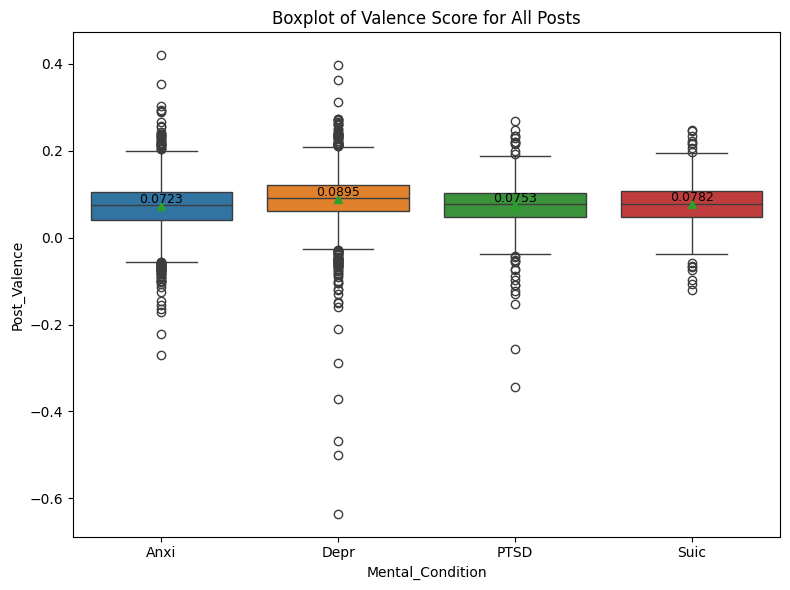

In [92]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Post_Valence", hue="Mental_Condition", data=mental_health_severity_analyse.dropna(), dodge=False, showmeans=True)
group_means = mental_health_severity_analyse.groupby("Mental_Condition")["Post_Valence"].mean()
for i, (condition, mean_val) in enumerate(group_means.items()):
    ax.text(i, mean_val, f"{mean_val:.4f}", 
            ha='center', va='bottom', fontsize=9, color="black")


labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.title("Boxplot of Valence Score for All Posts")
plt.tight_layout()
plt.show()

#### Arousal

C:\Users\putra\AppData\Local\Temp\ipykernel_49556\4042701198.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



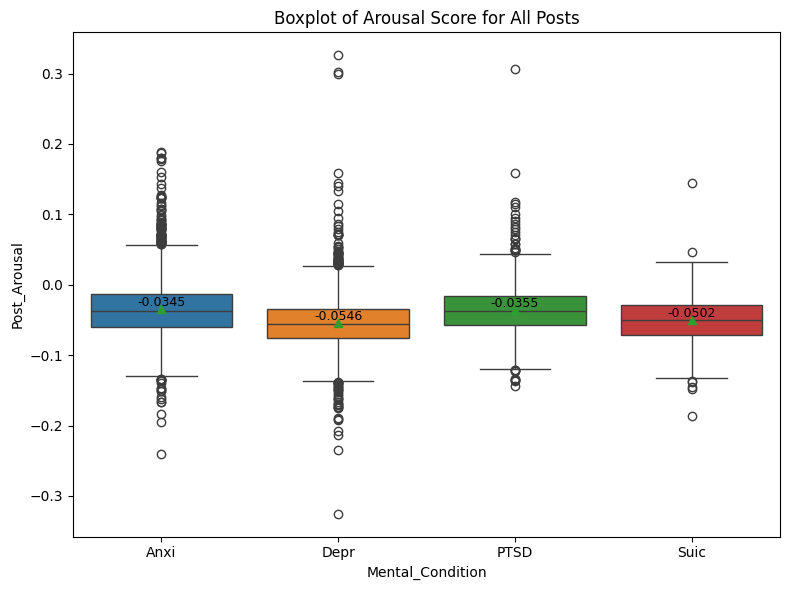

In [93]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Post_Arousal", hue="Mental_Condition", data=mental_health_severity_analyse.dropna(), dodge=False, showmeans=True)
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]

group_means = mental_health_severity_analyse.groupby("Mental_Condition")["Post_Arousal"].mean()
for i, (condition, mean_val) in enumerate(group_means.items()):
    ax.text(i, mean_val, f"{mean_val:.4f}", 
            ha='center', va='bottom', fontsize=9, color="black")
    
ax.set_xticklabels(labels)
plt.title("Boxplot of Arousal Score for All Posts")
plt.tight_layout()
plt.show()

#### Dominance

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\2813770541.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


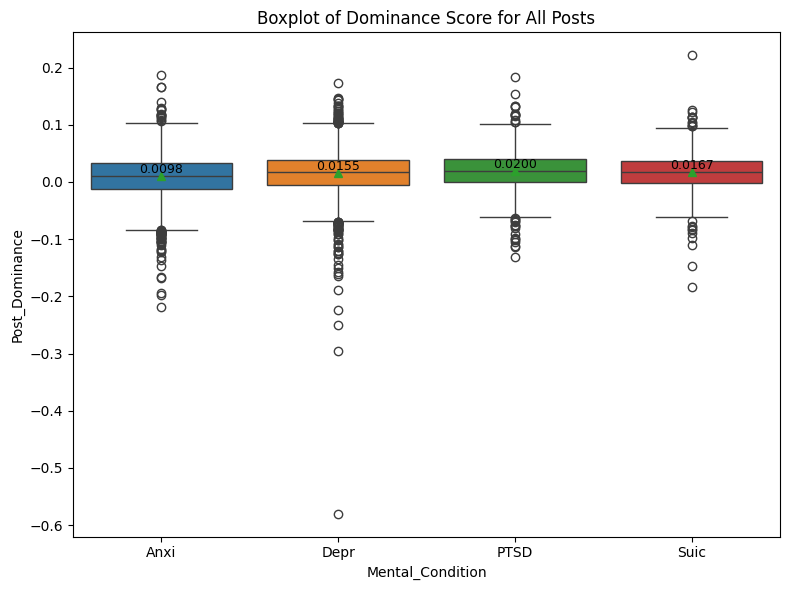

In [9]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Post_Dominance", hue="Mental_Condition", data=mental_health_severity_analyse.dropna(), dodge=False, showmeans=True)

group_means = mental_health_severity_analyse.groupby("Mental_Condition")["Post_Dominance"].mean()
for i, (condition, mean_val) in enumerate(group_means.items()):
    ax.text(i, mean_val, f"{mean_val:.4f}", 
            ha='center', va='bottom', fontsize=9, color="black")
    
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.title("Boxplot of Dominance Score for All Posts")
plt.tight_layout()
plt.show()

### VAD Post vs Last Comment 

#### Valence

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\3982165201.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])


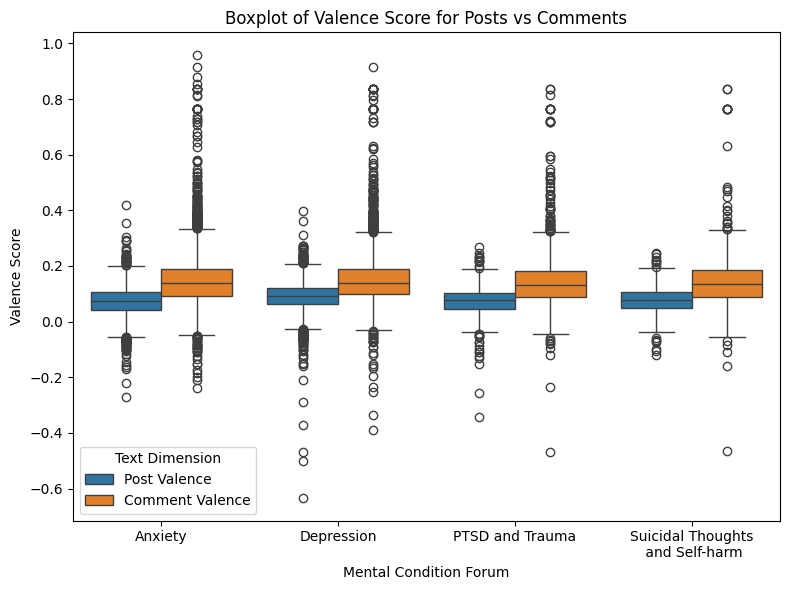

In [36]:
mental_health_severity_analyse_valence = mental_health_severity_analyse[['Post_Valence', 'Comment_Valence', 'Mental_Condition']].dropna()
mental_health_severity_analyse_valence_long = pd.melt(mental_health_severity_analyse_valence, id_vars=['Mental_Condition'], value_vars=['Post_Valence', 'Comment_Valence'], var_name='Type', value_name='Valence')

plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Valence", hue="Type", data=mental_health_severity_analyse_valence_long.dropna(), dodge=True)
ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])
ax.set_xlabel("Mental Condition Forum")
ax.set_ylabel("Valence Score")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, title="Text Dimension", labels=["Post Valence", "Comment Valence"], loc="best")
plt.title("Boxplot of Valence Score for Posts vs Comments")
plt.tight_layout()
plt.show()

#### Arousal

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\1451030778.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])


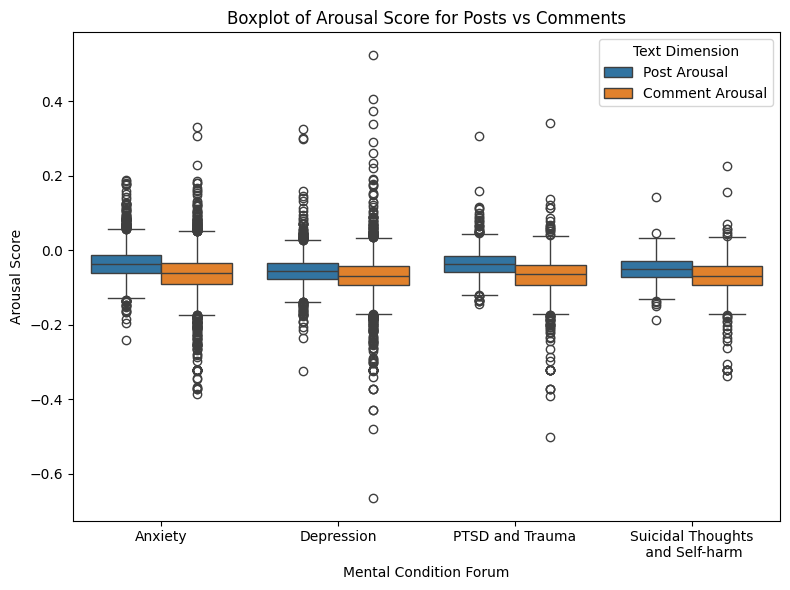

In [37]:
mental_health_severity_analyse_arousal = mental_health_severity_analyse[['Post_Arousal', 'Comment_Arousal', 'Mental_Condition']].dropna()
mental_health_severity_analyse_arousal_long = pd.melt(mental_health_severity_analyse_arousal, id_vars=['Mental_Condition'], value_vars=['Post_Arousal', 'Comment_Arousal'], var_name='Type', value_name='Arousal')

plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Arousal", hue="Type", data=mental_health_severity_analyse_arousal_long.dropna(), dodge=True)
ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])
ax.set_xlabel("Mental Condition Forum")
ax.set_ylabel("Arousal Score")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, title="Text Dimension", labels=["Post Arousal", "Comment Arousal"], loc="best")
plt.title("Boxplot of Arousal Score for Posts vs Comments")
plt.tight_layout()
plt.show()

#### Dominance

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\617070394.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])


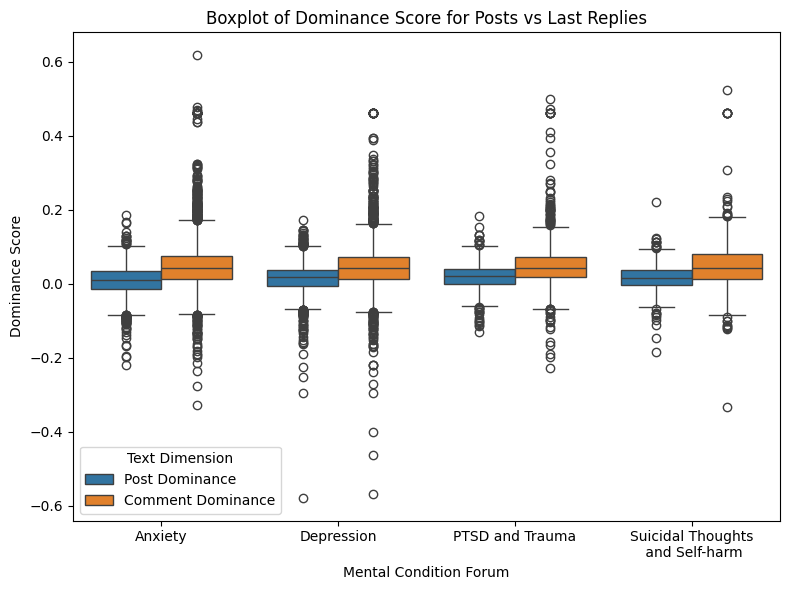

In [40]:
mental_health_severity_analyse_dominance = mental_health_severity_analyse[['Post_Dominance', 'Comment_Dominance', 'Mental_Condition']].dropna()
mental_health_severity_analyse_dominance_long = pd.melt(mental_health_severity_analyse_dominance, id_vars=['Mental_Condition'], value_vars=['Post_Dominance', 'Comment_Dominance'], var_name='Type', value_name='Dominance')

plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Mental_Condition", y="Dominance", hue="Type", data=mental_health_severity_analyse_dominance_long.dropna(), dodge=True)
ax.set_xticklabels(["Anxiety", "Depression", "PTSD and Trauma", "Suicidal Thoughts\n and Self-harm"])
ax.set_xlabel("Mental Condition Forum")
ax.set_ylabel("Dominance Score")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, title="Text Dimension", labels=["Post Dominance", "Comment Dominance"], loc="best")
plt.title("Boxplot of Dominance Score for Posts vs Last Replies")
plt.tight_layout()
plt.show()

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\3444095929.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\putra\AppData\Local\Temp\ipykernel_7488\3444095929.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\putra\AppData\Local\Temp\ipykernel_7488\3444095929.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


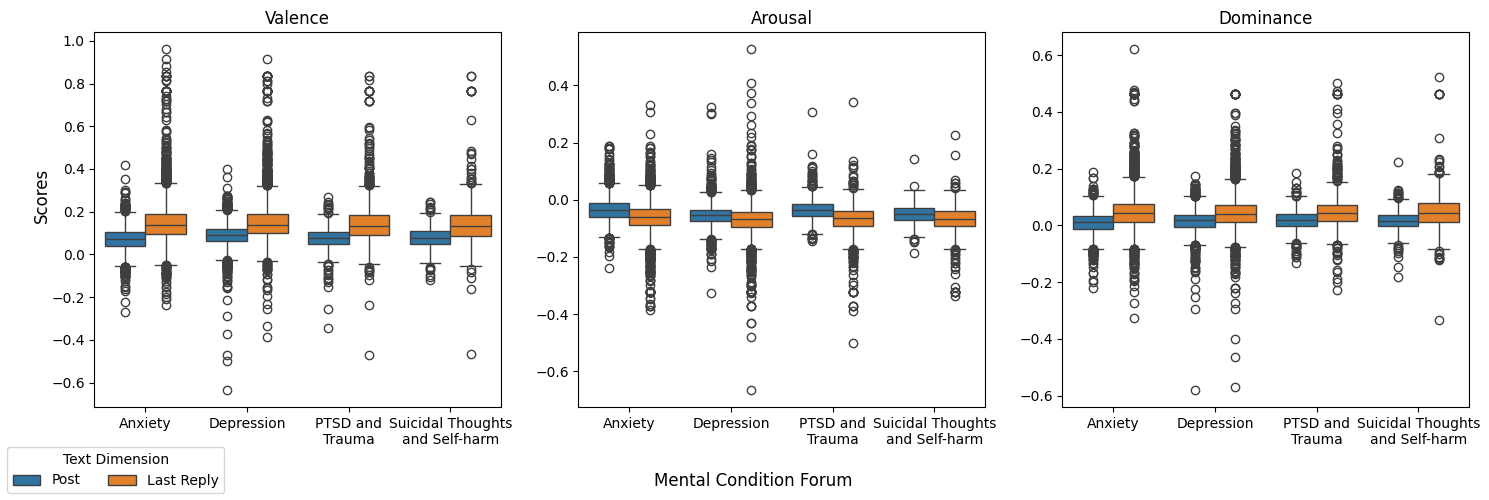

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=False)

plot_specs = [
    (mental_health_severity_analyse_valence_long, "Valence Score",    "Valence"),
    (mental_health_severity_analyse_arousal_long, "Arousal Score",    "Arousal"),
    (mental_health_severity_analyse_dominance_long, "Dominance Score",  "Dominance"),
]

for ax, (df, ylabel, title) in zip(axes, plot_specs):

    sns.boxplot(
        x="Mental_Condition",
        y=df.columns[df.columns.str.contains("Valence|Arousal|Dominance")][0],  # the score col
        hue="Type",
        data=df,
        dodge=True,
        showmeans=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("")           # remove per-subplot x-labels
    ax.set_ylabel("")

    # Nice wrapped x-tick labels
    ax.set_xticklabels([
        "Anxiety",
        "Depression",
        "PTSD and\nTrauma",
        "Suicidal Thoughts\nand Self-harm"
    ])

# ---- Shared y-axis label ----
fig.supylabel("Scores", y=0.6)

# ---- Single legend for all three ----
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

fig.legend(
    handles,
    ["Post", "Last Reply"],
    title="Text Dimension",    
    loc="lower left",
    ncol=2
)

fig.supxlabel("Mental Condition Forum")
fig.tight_layout(rect=[0, 0, 1, 1])   # leave space at bottom for legend
plt.show()


#### Post-Last Reply Difference Distribution

C:\Users\putra\AppData\Local\Temp\ipykernel_7488\1313628597.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Valence", "Arousal", "Dominance"])


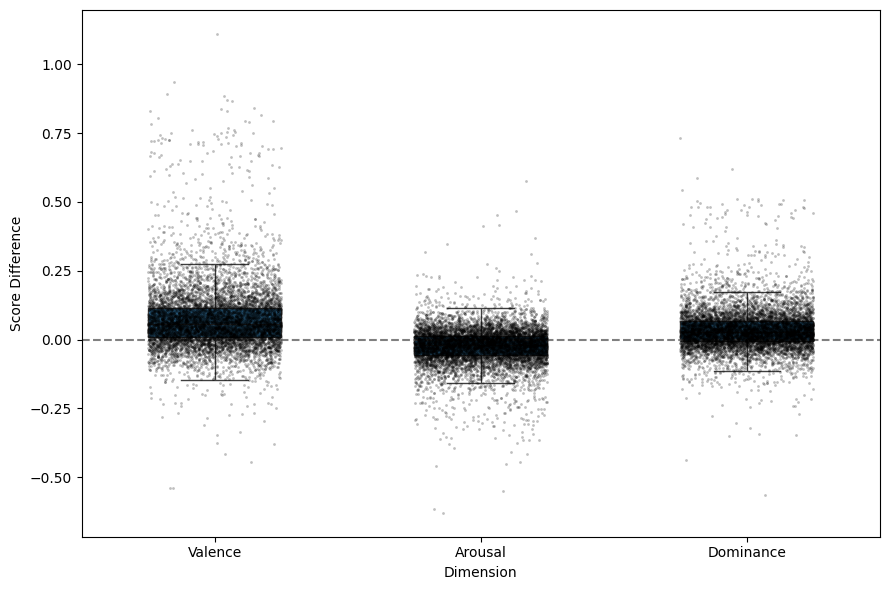

In [ ]:
mental_health_severity_analyse_diff = mental_health_severity_analyse[['Valence_Diff', 'Arousal_Diff', 'Dominance_Diff']].dropna().copy()
mental_health_severity_analyse_diff_long = pd.melt(mental_health_severity_analyse_diff, value_vars=['Valence_Diff', 'Arousal_Diff', 'Dominance_Diff'], var_name='Dimension', value_name='Score_Diff')

plt.figure(figsize=(9, 6))

# Base boxplot
ax = sns.boxplot(
    x="Dimension", 
    y="Score_Diff",
    data=mental_health_severity_analyse_diff_long,
    showcaps=True,
    showfliers=False,           # hide default dots
    boxprops={"zorder": 2},
    width=0.5
)

# Add jittered points
sns.stripplot(
    x="Dimension",
    y="Score_Diff",
    data=mental_health_severity_analyse_diff_long,
    color="black",
    alpha=0.25,
    jitter=0.25,
    size=2
)

# Optional: rename labels
ax.set_xticklabels(["Valence", "Arousal", "Dominance"])

plt.axhline(0, linestyle="--", color="grey")  # reference line
# plt.title("Distribution of Score Differences")
plt.ylabel("Score Difference")
plt.xlabel("Dimensions")

plt.tight_layout()
plt.show()


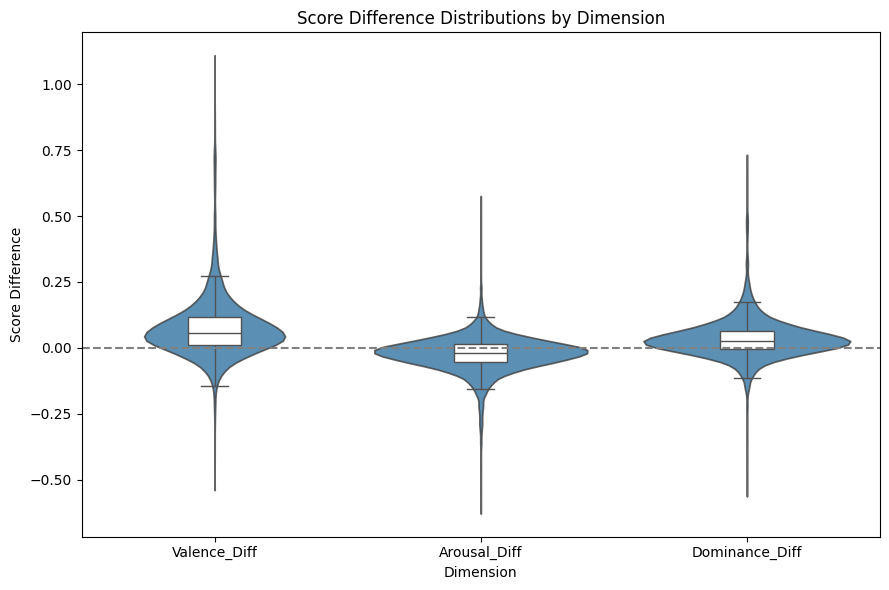

In [74]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    x="Dimension",
    y="Score_Diff",
    data=mental_health_severity_analyse_diff_long,
    inner=None,
    cut=0,
    alpha=0.8
)

sns.boxplot(
    x="Dimension",
    y="Score_Diff",
    data=mental_health_severity_analyse_diff_long,
    width=0.2,
    showcaps=True,
    boxprops={"zorder": 2, "facecolor": "white"},
    showfliers=False,
    whis=1.5
)

plt.axhline(0, linestyle="--", color="grey")
plt.title("Score Difference Distributions by Dimension")
plt.ylabel("Score Difference")
plt.xlabel("Dimension")
plt.tight_layout()
plt.show()


### Scatter Plot of Posts

In [77]:
valence = mental_health_severity_analyse['Post_Valence'].copy()
arousal = mental_health_severity_analyse['Post_Arousal'].copy()
dominance = mental_health_severity_analyse['Post_Dominance'].copy()
mental_condition = mental_health_severity_analyse['Mental_Condition'].copy()

In [80]:

color_map = {
    "Anxi": "#3cb44b",
    "Depr": "#4363d8",
    "PTSD": "#ff7f00",
    "Suic": "#e6194b"
}
colors = [color_map[cat] for cat in mental_condition]

fig = go.Figure(data=[go.Scatter3d(
    x=valence,
    y=arousal,
    z=dominance,
    mode='markers+text',
    textposition="top center",
    marker=dict(size=1.5, color=colors, opacity=0.5),
    showlegend=False
)])

# Axis labels
fig.update_layout(
    width=900,
    height=700,
    scene=dict(
        xaxis=dict(title="Valence (Pleasantness)", range=[-1, 1]),
        yaxis=dict(title="Arousal (Activation)", range=[-1, 1]),
        zaxis=dict(title="Dominance (Control)", range=[-1, 1])
    ),
    title="Interactive 3D VAD Space",
    legend=dict(
        title="Categories",
        itemsizing="constant"
    )

)

# Legend
for cat in color_map:
    idx = [i for i, m in enumerate(mental_condition) if m == cat]
    fig.add_trace(go.Scatter3d(
        x=valence[idx],
        y=arousal[idx],
        z=dominance[idx],
        mode="markers",
        marker=dict(size=1.5, color=color_map[cat], opacity=0.5),
        name=cat  # appears in legend
    ))

fig.show()



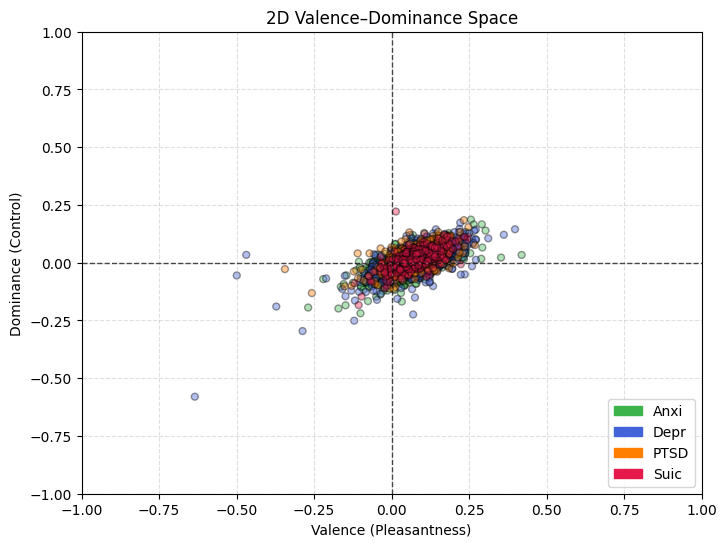

In [81]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(valence, dominance, c=colors, s=25, alpha=0.4, edgecolors="k")

# Axis labels and title
plt.xlabel("Valence (Pleasantness)")
plt.ylabel("Dominance (Control)")
plt.title("2D Valence–Dominance Space")

# Zero lines
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # y = 0
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # x = 0

# Axis limits
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=cat) for cat, c in color_map.items()]
plt.legend(handles=handles, loc="lower right")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


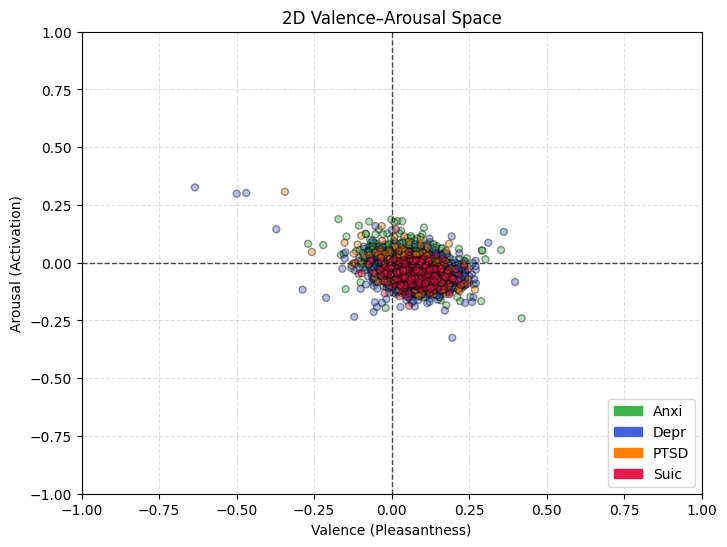

In [82]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(valence, arousal, c=colors, s=25, alpha=0.4, edgecolors="k")

# Axis labels and title
plt.xlabel("Valence (Pleasantness)")
plt.ylabel("Arousal (Activation)")
plt.title("2D Valence–Arousal Space")

# Zero lines
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # y = 0
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # x = 0

# Axis limits
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=cat) for cat, c in color_map.items()]
plt.legend(handles=handles, loc="lower right")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


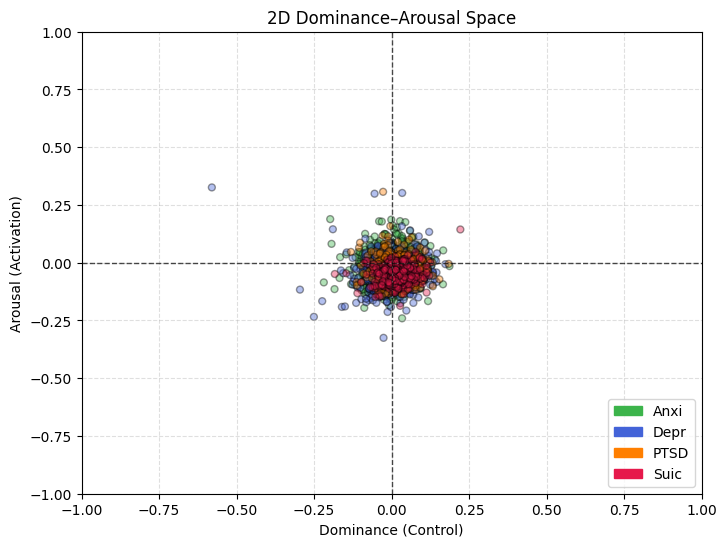

In [83]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(dominance, arousal, c=colors, s=25, alpha=0.4, edgecolors="k")

# Axis labels and title
plt.xlabel("Dominance (Control)")
plt.ylabel("Arousal (Activation)")
plt.title("2D Dominance–Arousal Space")

# Zero lines
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # y = 0
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)  # x = 0

# Axis limits
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=cat) for cat, c in color_map.items()]
plt.legend(handles=handles, loc="lower right")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


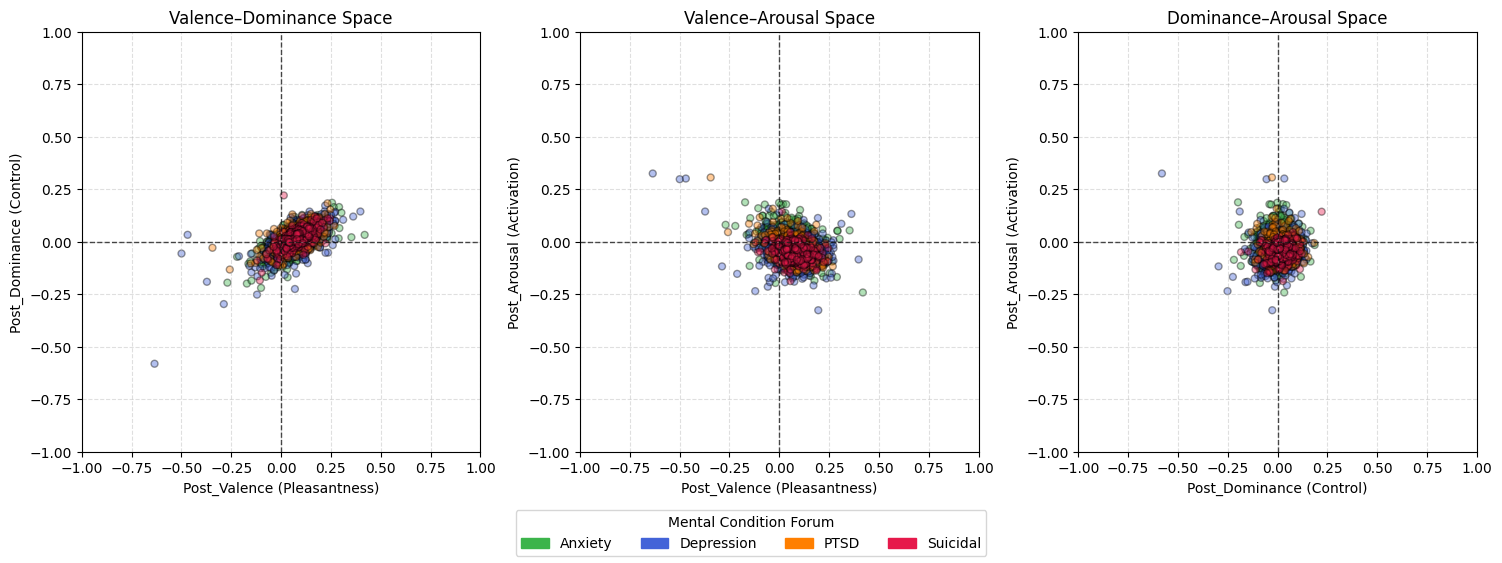

In [93]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the three pairs
pairs = [
    ("Post_Valence", "Post_Dominance", "Valence–Dominance Space"),
    ("Post_Valence", "Post_Arousal",   "Valence–Arousal Space"),
    ("Post_Dominance", "Post_Arousal", "Dominance–Arousal Space")
]

# Colors per category
colors = [color_map[c] for c in mental_condition]

for ax, (xvar, yvar, title) in zip(axes, pairs):

    # Scatter
    ax.scatter(
        mental_health_severity_analyse[xvar],
        mental_health_severity_analyse[yvar],
        c=colors,
        s=25,
        alpha=0.4,
        edgecolors="k"
    )

    # Titles and labels
    ax.set_title(title)
    ax.set_xlabel(f"{xvar} ({'Pleasantness' if xvar=='Post_Valence' else 'Control'})"
                  if xvar!='Post_Arousal' else f"{xvar} (Activation)")
    ax.set_ylabel(f"{yvar} ({'Pleasantness' if yvar=='Post_Valence' else 'Control'})"
                  if yvar!='Post_Arousal' else f"{yvar} (Activation)")

    # Zero lines
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

    # Axis limits
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

    # Grid
    ax.grid(True, linestyle="--", alpha=0.4)

# ---- Shared legend (same as your original style) ----
handles = [mpatches.Patch(color=c, label=cat) for cat, c in color_map.items()]
fig.legend(
    handles,
    [ "Anxiety", "Depression", "PTSD", "Suicidal" ],
    title="Mental Condition Forum",
    loc="lower center",
    ncol=4
)

# Space for legend
fig.subplots_adjust(bottom=0.18, wspace=0.25)

plt.show()



## Inference

### Changes in Mental Health Severity

#### Check Normality

##### Valence

In [102]:
post_valence = mental_health_severity_analyse_valence['Post_Valence']
comment_valence = mental_health_severity_analyse_valence['Comment_Valence']

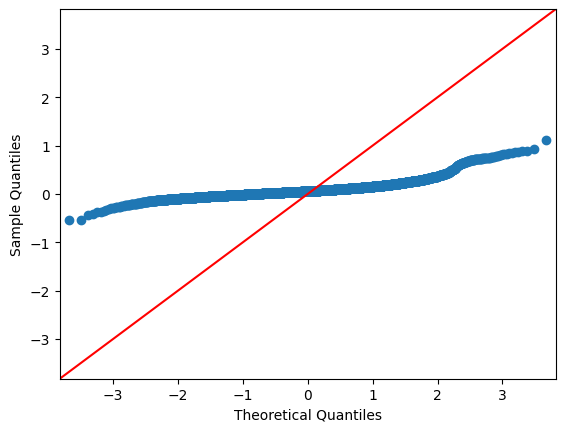

In [103]:
# Q-Q plot for Valence Difference
sm.qqplot(comment_valence - post_valence, line="45")
plt.show()

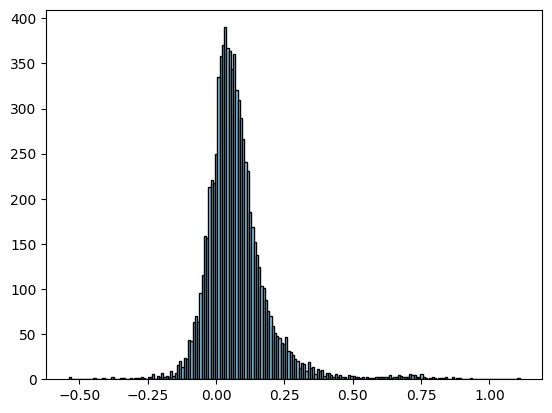

In [104]:
# Histogram
plt.hist(comment_valence - post_valence, bins=200, color="skyblue", edgecolor="black")
plt.show()


In [105]:
# skewness and kurtosis
print(stats.skew(comment_valence - post_valence))
print(stats.kurtosis(comment_valence - post_valence))

2.104651357775247
10.0630061756129


In [106]:
print(stats.shapiro(comment_valence.sample(5000, random_state=42) - post_valence.sample(5000, random_state=42)))  # Shapiro-Wilk test for normality
print(stats.normaltest(comment_valence - post_valence))  # D'Agostino and Pearson's test for normality

ShapiroResult(statistic=np.float64(0.837719331917202), pvalue=np.float64(1.0487047289544424e-57))
NormaltestResult(statistic=np.float64(4095.9624909293893), pvalue=np.float64(0.0))


##### Arousal

In [64]:
post_arousal = mental_health_severity_analyse_arousal['Post_Arousal']
comment_arousal = mental_health_severity_analyse_arousal['Comment_Arousal']

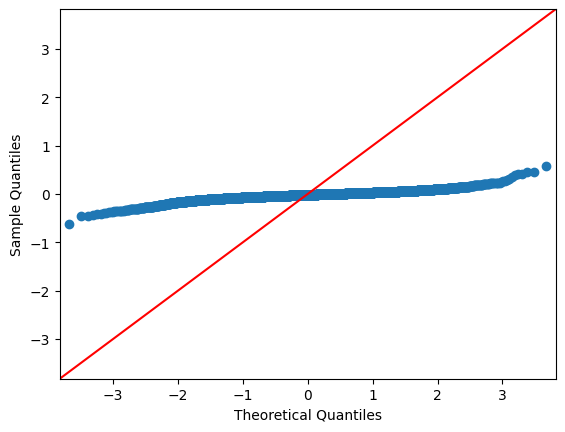

In [65]:
# Q-Q plot for Arousal Difference
sm.qqplot(comment_arousal - post_arousal, line="45")
plt.show()

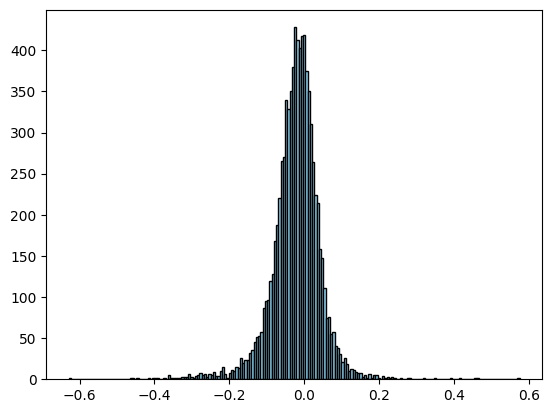

In [66]:
# Histogram for Arousal Difference
plt.hist(comment_arousal - post_arousal, bins=200, color="skyblue", edgecolor="black")
plt.show()

In [67]:
# skewness and kurtosis
print(stats.skew(comment_arousal - post_arousal))
print(stats.kurtosis(comment_arousal - post_arousal))

-0.6184005845985713
7.016142298394586


In [68]:
print(stats.shapiro(comment_arousal.sample(5000, random_state=42) - post_arousal.sample(5000, random_state=42)))  # Shapiro-Wilk test for normality
print(stats.normaltest(comment_arousal - post_arousal))  # D'Agostino and Pearson's test for normality

ShapiroResult(statistic=np.float64(0.9188250372150523), pvalue=np.float64(9.139626923340598e-46))
NormaltestResult(statistic=np.float64(1636.42707402443), pvalue=np.float64(0.0))


##### Dominance

In [85]:
post_dominance = mental_health_severity_analyse_dominance['Post_Dominance']
comment_dominance = mental_health_severity_analyse_dominance['Comment_Dominance']

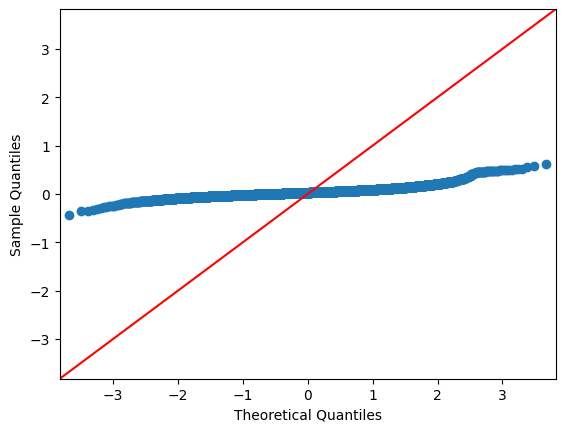

In [86]:
# Q-Q plot for Dominance Difference
sm.qqplot(comment_dominance - post_dominance, line="45")
plt.show()

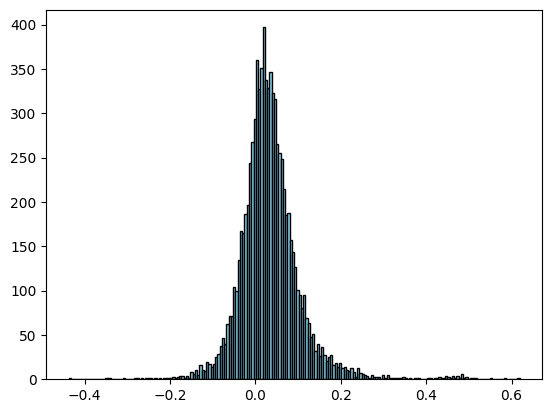

In [87]:
# Histogram for Arousal Difference
plt.hist(comment_dominance - post_dominance, bins=200, color="skyblue", edgecolor="black")
plt.show()

In [88]:
# skewness and kurtosis
print(stats.skew(comment_dominance - post_dominance))
print(stats.kurtosis(comment_dominance - post_dominance))

1.4988326598961077
8.543928290438007


In [89]:
print(stats.shapiro(comment_dominance.sample(5000, random_state=42) - post_dominance.sample(5000, random_state=42)))  # Shapiro-Wilk test for normality
print(stats.normaltest(comment_dominance - post_dominance))  # D'Agostino and Pearson's test for normality

ShapiroResult(statistic=np.float64(0.8886162483132298), pvalue=np.float64(4.8403972636536455e-51))
NormaltestResult(statistic=np.float64(3085.0413431202924), pvalue=np.float64(0.0))


#### Paired Observation Hotelling's T^2

In [105]:
post_vad = mental_health_severity_analyse[['Post_Valence', 'Post_Arousal', 'Post_Dominance']].copy()
comment_vad = mental_health_severity_analyse[['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']].copy()

pg.multivariate_ttest(comment_vad, post_vad, paired=True)

,T2,F,df1,df2,pval
hotelling,3542.855755,1180.670203,3,8382,0.0


In [ ]:
post_depression = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'Depr'][['Post_Valence', 'Post_Arousal', 'Post_Dominance']].copy()
comment_depression = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'Depr'][['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']].copy()

pg.multivariate_ttest(comment_depression, post_depression, paired=True)

,T2,F,df1,df2,pval
hotelling,1104.469151,367.92513,3,3182,3.948243e-205


In [242]:
post_ptsd = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'PTSD'][['Post_Valence', 'Post_Arousal', 'Post_Dominance']].copy()
comment_ptsd = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'PTSD'][['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']].copy()

pg.multivariate_ttest(comment_ptsd, post_ptsd, paired=True)

,T2,F,df1,df2,pval
hotelling,429.088412,142.747083,3,1011,4.051347e-77


In [243]:
post_suic = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'Suic'][['Post_Valence', 'Post_Arousal', 'Post_Dominance']].copy()
comment_suic = mental_health_severity_analyse[mental_health_severity_analyse['Mental_Condition'] == 'Suic'][['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']].copy()

pg.multivariate_ttest(comment_suic, post_suic, paired=True)

,T2,F,df1,df2,pval
hotelling,162.446078,53.947021,3,535,1.773023e-30


#### Paired t-Test

##### Valence

In [106]:
post_valence_depr = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Depr']['Post_Valence'].copy()
comment_valence_depr = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Depr']['Comment_Valence'].copy()
post_valence_anxi = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Anxi']['Post_Valence'].copy()
comment_valence_anxi = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Anxi']['Comment_Valence'].copy()
post_valence_ptsd = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'PTSD']['Post_Valence'].copy()
comment_valence_ptsd = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'PTSD']['Comment_Valence'].copy()
post_valence_suic = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Suic']['Post_Valence'].copy()
comment_valence_suic = mental_health_severity_analyse_valence[mental_health_severity_analyse_valence['Mental_Condition'] == 'Suic']['Comment_Valence'].copy()

###### Depression

In [107]:
t_stat, p_val = stats.ttest_rel(comment_valence_depr, post_valence_depr)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_depr - post_valence_depr).mean()],
    "Variance of Differences": [(comment_valence_depr - post_valence_depr).var(ddof=1)],
    "Std Error": [(comment_valence_depr - post_valence_depr).std(ddof=1) / np.sqrt(len(post_valence_depr))],
    "N": [len(post_valence_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.95963,3.052114e-205,0.067412,0.013323,0.002045,3185


In [108]:
t_stat, p_val = stats.ttest_rel(comment_valence_depr, post_valence_depr, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_depr - post_valence_depr).mean()],
    "Variance of Differences": [(comment_valence_depr - post_valence_depr).var(ddof=1)],
    "Std Error": [(comment_valence_depr - post_valence_depr).std(ddof=1) / np.sqrt(len(post_valence_depr))],
    "N": [len(post_valence_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.95963,1.526057e-205,0.067412,0.013323,0.002045,3185


In [109]:
t_stat, p_val = stats.ttest_rel(comment_valence_depr, post_valence_depr, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_depr - post_valence_depr).mean()],
    "Variance of Differences": [(comment_valence_depr - post_valence_depr).var(ddof=1)],
    "Std Error": [(comment_valence_depr - post_valence_depr).std(ddof=1) / np.sqrt(len(post_valence_depr))],
    "N": [len(post_valence_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.95963,1.0,0.067412,0.013323,0.002045,3185


###### Anxiety

In [110]:
t_stat, p_val = stats.ttest_rel(comment_valence_anxi, post_valence_anxi,)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_anxi - post_valence_anxi).mean()],
    "Variance of Differences": [(comment_valence_anxi - post_valence_anxi).var(ddof=1)],
    "Std Error": [(comment_valence_anxi - post_valence_anxi).std(ddof=1) / np.sqrt(len(post_valence_anxi))],
    "N": [len(post_valence_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,42.471477,1.292476e-320,0.080944,0.01325,0.001906,3648


In [111]:
t_stat, p_val = stats.ttest_rel(comment_valence_anxi, post_valence_anxi, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_anxi - post_valence_anxi).mean()],
    "Variance of Differences": [(comment_valence_anxi - post_valence_anxi).var(ddof=1)],
    "Std Error": [(comment_valence_anxi - post_valence_anxi).std(ddof=1) / np.sqrt(len(post_valence_anxi))],
    "N": [len(post_valence_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,42.471477,6.462379e-321,0.080944,0.01325,0.001906,3648


In [112]:
t_stat, p_val = stats.ttest_rel(comment_valence_anxi, post_valence_anxi, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_anxi - post_valence_anxi).mean()],
    "Variance of Differences": [(comment_valence_anxi - post_valence_anxi).var(ddof=1)],
    "Std Error": [(comment_valence_anxi - post_valence_anxi).std(ddof=1) / np.sqrt(len(post_valence_anxi))],
    "N": [len(post_valence_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,42.471477,1.0,0.080944,0.01325,0.001906,3648


###### PTSD and Trauma

In [113]:
t_stat, p_val = stats.ttest_rel(comment_valence_ptsd, post_valence_ptsd)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_ptsd - post_valence_ptsd).mean()],
    "Variance of Differences": [(comment_valence_ptsd - post_valence_ptsd).var(ddof=1)],
    "Std Error": [(comment_valence_ptsd - post_valence_ptsd).std(ddof=1) / np.sqrt(len(post_valence_ptsd))],
    "N": [len(post_valence_ptsd)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,19.291674,7.134054e-71,0.076441,0.01592,0.003962,1014


In [114]:
t_stat, p_val = stats.ttest_rel(comment_valence_ptsd, post_valence_ptsd, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_ptsd - post_valence_ptsd).mean()],
    "Variance of Differences": [(comment_valence_ptsd - post_valence_ptsd).var(ddof=1)],
    "Std Error": [(comment_valence_ptsd - post_valence_ptsd).std(ddof=1) / np.sqrt(len(post_valence_ptsd))],
    "N": [len(post_valence_ptsd)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,19.291674,3.567027e-71,0.076441,0.01592,0.003962,1014


In [115]:
t_stat, p_val = stats.ttest_rel(comment_valence_ptsd, post_valence_ptsd, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_ptsd - post_valence_ptsd).mean()],
    "Variance of Differences": [(comment_valence_ptsd - post_valence_ptsd).var(ddof=1)],
    "Std Error": [(comment_valence_ptsd - post_valence_ptsd).std(ddof=1) / np.sqrt(len(post_valence_ptsd))],
    "N": [len(post_valence_ptsd)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,19.291674,1.0,0.076441,0.01592,0.003962,1014


###### Suicidal Thoughts and Self-Harm

In [116]:
t_stat, p_val = stats.ttest_rel(comment_valence_suic, post_valence_suic)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_suic - post_valence_suic).mean()],
    "Variance of Differences": [(comment_valence_suic - post_valence_suic).var(ddof=1)],
    "Std Error": [(comment_valence_suic - post_valence_suic).std(ddof=1) / np.sqrt(len(post_valence_suic))],
    "N": [len(post_valence_suic)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,12.485722,1.371266e-31,0.071011,0.017402,0.005687,538


In [59]:
t_stat, p_val = stats.ttest_rel(comment_valence_suic, post_valence_suic, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_suic - post_valence_suic).mean()],
    "Variance of Differences": [(comment_valence_suic - post_valence_suic).var(ddof=1)],
    "Std Error": [(comment_valence_suic - post_valence_suic).std(ddof=1) / np.sqrt(len(post_valence_suic))],
    "N": [len(post_valence_suic)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,12.335282,2.952762e-31,0.068027,0.016363,0.005515,538


In [117]:
t_stat, p_val = stats.ttest_rel(comment_valence_suic, post_valence_suic, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_valence_suic - post_valence_suic).mean()],
    "Variance of Differences": [(comment_valence_suic - post_valence_suic).var(ddof=1)],
    "Std Error": [(comment_valence_suic - post_valence_suic).std(ddof=1) / np.sqrt(len(post_valence_suic))],
    "N": [len(post_valence_suic)]
})


alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,12.485722,1.0,0.071011,0.017402,0.005687,538


##### Arousal

In [118]:
post_arousal_depr = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Depr']['Post_Arousal'].copy()
comment_arousal_depr = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Depr']['Comment_Arousal'].copy()
post_arousal_anxi = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Anxi']['Post_Arousal'].copy()
comment_arousal_anxi = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Anxi']['Comment_Arousal'].copy()
post_arousal_ptsd = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'PTSD']['Post_Arousal'].copy()
comment_arousal_ptsd = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'PTSD']['Comment_Arousal'].copy()
post_arousal_suic = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Suic']['Post_Arousal'].copy()
comment_arousal_suic = mental_health_severity_analyse_arousal[mental_health_severity_analyse_arousal['Mental_Condition'] == 'Suic']['Comment_Arousal'].copy()

###### Depression

In [120]:
t_stat, p_val = stats.ttest_rel(comment_arousal_depr, post_arousal_depr)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_depr - post_arousal_depr).mean()],
    "Variance of Differences": [(comment_arousal_depr - post_arousal_depr).var(ddof=1)],
    "Std Error": [(comment_arousal_depr - post_arousal_depr).std(ddof=1) / np.sqrt(len(post_arousal_depr))],
    "N": [len(post_arousal_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-12.623576,1.104825e-35,-0.015069,0.004539,0.001194,3185


In [121]:
t_stat, p_val = stats.ttest_rel(comment_arousal_depr, post_arousal_depr, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_depr - post_arousal_depr).mean()],
    "Variance of Differences": [(comment_arousal_depr - post_arousal_depr).var(ddof=1)],
    "Std Error": [(comment_arousal_depr - post_arousal_depr).std(ddof=1) / np.sqrt(len(post_arousal_depr))],
    "N": [len(post_arousal_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-12.623576,1.0,-0.015069,0.004539,0.001194,3185


In [122]:
t_stat, p_val = stats.ttest_rel(comment_arousal_depr, post_arousal_depr, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_depr - post_arousal_depr).mean()],
    "Variance of Differences": [(comment_arousal_depr - post_arousal_depr).var(ddof=1)],
    "Std Error": [(comment_arousal_depr - post_arousal_depr).std(ddof=1) / np.sqrt(len(post_arousal_depr))],
    "N": [len(post_arousal_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-12.623576,5.524127e-36,-0.015069,0.004539,0.001194,3185


###### Anxiety

In [123]:
t_stat, p_val = stats.ttest_rel(comment_arousal_anxi, post_arousal_anxi)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_anxi - post_arousal_anxi).mean()],
    "Variance of Differences": [(comment_arousal_anxi - post_arousal_anxi).var(ddof=1)],
    "Std Error": [(comment_arousal_anxi - post_arousal_anxi).std(ddof=1) / np.sqrt(len(post_arousal_anxi))],
    "N": [len(post_arousal_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-25.663059,1.144983e-133,-0.028378,0.004461,0.001106,3648


In [124]:
t_stat, p_val = stats.ttest_rel(comment_arousal_anxi, post_arousal_anxi, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_anxi - post_arousal_anxi).mean()],
    "Variance of Differences": [(comment_arousal_anxi - post_arousal_anxi).var(ddof=1)],
    "Std Error": [(comment_arousal_anxi - post_arousal_anxi).std(ddof=1) / np.sqrt(len(post_arousal_anxi))],
    "N": [len(post_arousal_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-25.663059,1.0,-0.028378,0.004461,0.001106,3648


In [126]:
t_stat, p_val = stats.ttest_rel(comment_arousal_anxi, post_arousal_anxi, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_anxi - post_arousal_anxi).mean()],
    "Variance of Differences": [(comment_arousal_anxi - post_arousal_anxi).var(ddof=1)],
    "Std Error": [(comment_arousal_anxi - post_arousal_anxi).std(ddof=1) / np.sqrt(len(post_arousal_anxi))],
    "N": [len(post_arousal_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-25.663059,5.724916e-134,-0.028378,0.004461,0.001106,3648


###### PTSD and Trauma

In [130]:
t_stat, p_val = stats.ttest_rel(comment_arousal_ptsd, post_arousal_ptsd)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_ptsd - post_arousal_ptsd).mean()],
    "Variance of Differences": [(comment_arousal_ptsd - post_arousal_ptsd).var(ddof=1)],
    "Std Error": [(comment_arousal_ptsd - post_arousal_ptsd).std(ddof=1) / np.sqrt(len(post_arousal_ptsd))],
    "N": [len(post_arousal_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-15.728111,4.888540e-50,-0.034691,0.004933,0.002206,1014


In [129]:
t_stat, p_val = stats.ttest_rel(comment_arousal_ptsd, post_arousal_ptsd, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_ptsd - post_arousal_ptsd).mean()],
    "Variance of Differences": [(comment_arousal_ptsd - post_arousal_ptsd).var(ddof=1)],
    "Std Error": [(comment_arousal_ptsd - post_arousal_ptsd).std(ddof=1) / np.sqrt(len(post_arousal_ptsd))],
    "N": [len(post_arousal_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-15.728111,1.0,-0.034691,0.004933,0.002206,1014


In [128]:
t_stat, p_val = stats.ttest_rel(comment_arousal_ptsd, post_arousal_ptsd, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_ptsd - post_arousal_ptsd).mean()],
    "Variance of Differences": [(comment_arousal_ptsd - post_arousal_ptsd).var(ddof=1)],
    "Std Error": [(comment_arousal_ptsd - post_arousal_ptsd).std(ddof=1) / np.sqrt(len(post_arousal_ptsd))],
    "N": [len(post_arousal_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-15.728111,2.444270e-50,-0.034691,0.004933,0.002206,1014


###### Suicidal Thoughts and Self-harm

In [131]:
t_stat, p_val = stats.ttest_rel(comment_arousal_suic, post_arousal_suic)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_suic - post_arousal_suic).mean()],
    "Variance of Differences": [(comment_arousal_suic - post_arousal_suic).var(ddof=1)],
    "Std Error": [(comment_arousal_suic - post_arousal_suic).std(ddof=1) / np.sqrt(len(post_arousal_suic))],
    "N": [len(post_arousal_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-7.083606,4.427552e-12,-0.020433,0.004476,0.002885,538


In [82]:
t_stat, p_val = stats.ttest_rel(comment_arousal_suic, post_arousal_suic, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_suic - post_arousal_suic).mean()],
    "Variance of Differences": [(comment_arousal_suic - post_arousal_suic).var(ddof=1)],
    "Std Error": [(comment_arousal_suic - post_arousal_suic).std(ddof=1) / np.sqrt(len(post_arousal_suic))],
    "N": [len(post_arousal_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-7.083606,1.0,-0.020433,0.004476,0.002885,538


In [132]:
t_stat, p_val = stats.ttest_rel(comment_arousal_suic, post_arousal_suic, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_arousal_suic - post_arousal_suic).mean()],
    "Variance of Differences": [(comment_arousal_suic - post_arousal_suic).var(ddof=1)],
    "Std Error": [(comment_arousal_suic - post_arousal_suic).std(ddof=1) / np.sqrt(len(post_arousal_suic))],
    "N": [len(post_arousal_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,-7.083606,2.213776e-12,-0.020433,0.004476,0.002885,538


##### Dominance

In [137]:
post_dominance_depr = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Depr']['Post_Dominance'].copy()
comment_dominance_depr = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Depr']['Comment_Dominance'].copy()
post_dominance_anxi = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Anxi']['Post_Dominance'].copy()
comment_dominance_anxi = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Anxi']['Comment_Dominance'].copy()
post_dominance_ptsd = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'PTSD']['Post_Dominance'].copy()
comment_dominance_ptsd = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'PTSD']['Comment_Dominance'].copy()
post_dominance_suic = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Suic']['Post_Dominance'].copy()
comment_dominance_suic = mental_health_severity_analyse_dominance[mental_health_severity_analyse_dominance['Mental_Condition'] == 'Suic']['Comment_Dominance'].copy()

###### Depression

In [139]:
t_stat, p_val = stats.ttest_rel(comment_dominance_depr, post_dominance_depr)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_depr - post_dominance_depr).mean()],
    "Variance of Differences": [(comment_dominance_depr - post_dominance_depr).var(ddof=1)],
    "Std Error": [(comment_dominance_depr - post_dominance_depr).std(ddof=1) / np.sqrt(len(post_dominance_depr))],
    "N": [len(post_dominance_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,22.944201,6.055790e-108,0.030795,0.005738,0.001342,3185


In [140]:
t_stat, p_val = stats.ttest_rel(comment_dominance_depr, post_dominance_depr, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_depr - post_dominance_depr).mean()],
    "Variance of Differences": [(comment_dominance_depr - post_dominance_depr).var(ddof=1)],
    "Std Error": [(comment_dominance_depr - post_dominance_depr).std(ddof=1) / np.sqrt(len(post_dominance_depr))],
    "N": [len(post_dominance_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,22.944201,3.027895e-108,0.030795,0.005738,0.001342,3185


In [141]:
t_stat, p_val = stats.ttest_rel(comment_dominance_depr, post_dominance_depr, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_depr - post_dominance_depr).mean()],
    "Variance of Differences": [(comment_dominance_depr - post_dominance_depr).var(ddof=1)],
    "Std Error": [(comment_dominance_depr - post_dominance_depr).std(ddof=1) / np.sqrt(len(post_dominance_depr))],
    "N": [len(post_dominance_depr)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,22.944201,1.0,0.030795,0.005738,0.001342,3185


###### Anxiety

In [142]:
t_stat, p_val = stats.ttest_rel(comment_dominance_anxi, post_dominance_anxi)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_anxi - post_dominance_anxi).mean()],
    "Variance of Differences": [(comment_dominance_anxi - post_dominance_anxi).var(ddof=1)],
    "Std Error": [(comment_dominance_anxi - post_dominance_anxi).std(ddof=1) / np.sqrt(len(post_dominance_anxi))],
    "N": [len(post_dominance_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.15528,6.056386e-200,0.039851,0.005603,0.001239,3648


In [143]:
t_stat, p_val = stats.ttest_rel(comment_dominance_anxi, post_dominance_anxi, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_anxi - post_dominance_anxi).mean()],
    "Variance of Differences": [(comment_dominance_anxi - post_dominance_anxi).var(ddof=1)],
    "Std Error": [(comment_dominance_anxi - post_dominance_anxi).std(ddof=1) / np.sqrt(len(post_dominance_anxi))],
    "N": [len(post_dominance_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.15528,3.028193e-200,0.039851,0.005603,0.001239,3648


In [145]:
t_stat, p_val = stats.ttest_rel(comment_dominance_anxi, post_dominance_anxi, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_anxi - post_dominance_anxi).mean()],
    "Variance of Differences": [(comment_dominance_anxi - post_dominance_anxi).var(ddof=1)],
    "Std Error": [(comment_dominance_anxi - post_dominance_anxi).std(ddof=1) / np.sqrt(len(post_dominance_anxi))],
    "N": [len(post_dominance_anxi)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,32.15528,1.0,0.039851,0.005603,0.001239,3648


###### PTSD and Trauma

In [146]:
t_stat, p_val = stats.ttest_rel(comment_dominance_ptsd, post_dominance_ptsd)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_ptsd - post_dominance_ptsd).mean()],
    "Variance of Differences": [(comment_dominance_ptsd - post_dominance_ptsd).var(ddof=1)],
    "Std Error": [(comment_dominance_ptsd - post_dominance_ptsd).std(ddof=1) / np.sqrt(len(post_dominance_ptsd))],
    "N": [len(post_dominance_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,13.393031,8.838079e-38,0.031239,0.005517,0.002332,1014


In [147]:
t_stat, p_val = stats.ttest_rel(comment_dominance_ptsd, post_dominance_ptsd, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_ptsd - post_dominance_ptsd).mean()],
    "Variance of Differences": [(comment_dominance_ptsd - post_dominance_ptsd).var(ddof=1)],
    "Std Error": [(comment_dominance_ptsd - post_dominance_ptsd).std(ddof=1) / np.sqrt(len(post_dominance_ptsd))],
    "N": [len(post_dominance_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,13.393031,4.419039e-38,0.031239,0.005517,0.002332,1014


In [148]:
t_stat, p_val = stats.ttest_rel(comment_dominance_ptsd, post_dominance_ptsd, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_ptsd - post_dominance_ptsd).mean()],
    "Variance of Differences": [(comment_dominance_ptsd - post_dominance_ptsd).var(ddof=1)],
    "Std Error": [(comment_dominance_ptsd - post_dominance_ptsd).std(ddof=1) / np.sqrt(len(post_dominance_ptsd))],
    "N": [len(post_dominance_ptsd)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,13.393031,1.0,0.031239,0.005517,0.002332,1014


###### Suicidal Thoughts and Self-Harm

In [149]:
t_stat, p_val = stats.ttest_rel(comment_dominance_suic, post_dominance_suic)

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_suic - post_dominance_suic).mean()],
    "Variance of Differences": [(comment_dominance_suic - post_dominance_suic).var(ddof=1)],
    "Std Error": [(comment_dominance_suic - post_dominance_suic).std(ddof=1) / np.sqrt(len(post_dominance_suic))],
    "N": [len(post_dominance_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,9.144047,1.237587e-18,0.033633,0.007278,0.003678,538


In [150]:
t_stat, p_val = stats.ttest_rel(comment_dominance_suic, post_dominance_suic, alternative='greater')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_suic - post_dominance_suic).mean()],
    "Variance of Differences": [(comment_dominance_suic - post_dominance_suic).var(ddof=1)],
    "Std Error": [(comment_dominance_suic - post_dominance_suic).std(ddof=1) / np.sqrt(len(post_dominance_suic))],
    "N": [len(post_dominance_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Reject the null hypothesis: significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,9.144047,6.187934e-19,0.033633,0.007278,0.003678,538


In [151]:
t_stat, p_val = stats.ttest_rel(comment_dominance_suic, post_dominance_suic, alternative='less')

results = pd.DataFrame({
    "Test": ["Paired t-test"],
    "t-statistic": [t_stat],
    "p-value": [p_val],
    "Mean Difference": [(comment_dominance_suic - post_dominance_suic).mean()],
    "Variance of Differences": [(comment_dominance_suic - post_dominance_suic).var(ddof=1)],
    "Std Error": [(comment_dominance_suic - post_dominance_suic).std(ddof=1) / np.sqrt(len(post_dominance_suic))],
    "N": [len(post_dominance_suic)]
})

alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: significant difference")
else:
    print("Fail to reject the null hypothesis: no significant difference")

results

Fail to reject the null hypothesis: no significant difference


,Test,t-statistic,p-value,Mean Difference,Variance of Differences,Std Error,N
0,Paired t-test,9.144047,1.0,0.033633,0.007278,0.003678,538


#### Wilcoxon Signed-Rank Test

##### Valence

###### All Data

In [120]:
res = pg.wilcoxon(comment_valence, post_valence, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,4687998.0,two-sided,0.0,0.733321,0.762099


In [121]:
res = pg.wilcoxon(comment_valence, post_valence, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,30470307.0,greater,0.0,0.733321,0.762099


In [122]:
res = pg.wilcoxon(comment_valence, post_valence, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,30470307.0,less,1.0,0.733321,0.237901


###### Depression

In [123]:
res = pg.wilcoxon(comment_valence_depr, post_valence_depr, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,770781.0,two-sided,8.681496e-254,0.696166,0.743846


In [124]:
res = pg.wilcoxon(comment_valence_depr, post_valence_depr, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,4302924.0,greater,4.340748e-254,0.696166,0.743846


In [125]:
res = pg.wilcoxon(comment_valence_depr, post_valence_depr, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,4302924.0,less,1.0,0.696166,0.256154


###### Anxiety

In [126]:
res = pg.wilcoxon(comment_valence_anxi, post_valence_anxi, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,734699.0,two-sided,0.0,0.77923,0.782023


In [127]:
res = pg.wilcoxon(comment_valence_anxi, post_valence_anxi, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,5921077.0,greater,0.0,0.77923,0.782023


In [128]:
res = pg.wilcoxon(comment_valence_anxi, post_valence_anxi, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,5921077.0,less,1.0,0.77923,0.217977


###### PTSD and Trauma

In [129]:
res = pg.wilcoxon(comment_valence_ptsd, post_valence_ptsd, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,70883.0,two-sided,7.448192e-89,0.724515,0.758303


In [130]:
res = pg.wilcoxon(comment_valence_ptsd, post_valence_ptsd, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,443722.0,greater,3.724096e-89,0.724515,0.758303


In [131]:
res = pg.wilcoxon(comment_valence_ptsd, post_valence_ptsd, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,443722.0,less,1.0,0.724515,0.241697


###### Suicidal Thoughts and Self-Harm

In [132]:
res = pg.wilcoxon(comment_valence_suic, post_valence_suic, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,25871.0,two-sided,3.264027e-38,0.643136,0.745294


In [133]:
res = pg.wilcoxon(comment_valence_suic, post_valence_suic, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,119120.0,greater,1.632014e-38,0.643136,0.745294


In [134]:
res = pg.wilcoxon(comment_valence_suic, post_valence_suic, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,119120.0,less,1.0,0.643136,0.254706


##### Arousal

###### All

In [135]:
res = pg.wilcoxon(comment_arousal, post_arousal, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,10203504.0,two-sided,9.362327e-243,-0.419568,0.354394


In [136]:
res = pg.wilcoxon(comment_arousal, post_arousal, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,10203504.0,greater,1.0,-0.419568,0.354394


In [137]:
res = pg.wilcoxon(comment_arousal, post_arousal, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,10203504.0,less,4.681164e-243,-0.419568,0.645606


###### Depression

In [138]:
res = pg.wilcoxon(comment_arousal_depr, post_arousal_depr, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1814106.0,two-sided,4.436039e-44,-0.284899,0.400057


In [139]:
res = pg.wilcoxon(comment_arousal_depr, post_arousal_depr, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1814106.0,greater,1.0,-0.284899,0.400057


In [140]:
res = pg.wilcoxon(comment_arousal_depr, post_arousal_depr, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1814106.0,less,2.218020e-44,-0.284899,0.599943


###### Anxiety

In [141]:
res = pg.wilcoxon(comment_arousal_anxi, post_arousal_anxi, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1684213.0,two-sided,3.444107e-147,-0.493909,0.327651


In [142]:
res = pg.wilcoxon(comment_arousal_anxi, post_arousal_anxi, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1684213.0,greater,1.0,-0.493909,0.327651


In [143]:
res = pg.wilcoxon(comment_arousal_anxi, post_arousal_anxi, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1684213.0,less,1.722053e-147,-0.493909,0.672349


###### PTSD and Trauma

In [144]:
res = pg.wilcoxon(comment_arousal_ptsd, post_arousal_ptsd, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,109418.0,two-sided,1.322995e-56,-0.57475,0.293089


In [145]:
res = pg.wilcoxon(comment_arousal_ptsd, post_arousal_ptsd, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,109418.0,greater,1.0,-0.57475,0.293089


In [146]:
res = pg.wilcoxon(comment_arousal_ptsd, post_arousal_ptsd, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,109418.0,less,6.614974e-57,-0.57475,0.706911


###### Suicidal Thoughts and Self-Harm

In [147]:
res = pg.wilcoxon(comment_arousal_suic, post_arousal_suic, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,45850.0,two-sided,1.509511e-13,-0.367547,0.368636


In [148]:
res = pg.wilcoxon(comment_arousal_suic, post_arousal_suic, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,45850.0,greater,1.0,-0.367547,0.368636


In [149]:
res = pg.wilcoxon(comment_arousal_suic, post_arousal_suic, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,45850.0,less,7.547553e-14,-0.367547,0.631364


##### Dominance

###### All

In [150]:
res = pg.wilcoxon(comment_dominance, post_dominance, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,7821173.0,two-sided,0.0,0.555088,0.694149


In [151]:
res = pg.wilcoxon(comment_dominance, post_dominance, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,27337132.0,greater,0.0,0.555088,0.694149


In [152]:
res = pg.wilcoxon(comment_dominance, post_dominance, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,27337132.0,less,1.0,0.555088,0.305851


###### Depression

In [153]:
res = pg.wilcoxon(comment_dominance_depr, post_dominance_depr, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1233012.0,two-sided,2.883669e-139,0.51396,0.678847


In [154]:
res = pg.wilcoxon(comment_dominance_depr, post_dominance_depr, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,3840693.0,greater,1.441835e-139,0.51396,0.678847


In [155]:
res = pg.wilcoxon(comment_dominance_depr, post_dominance_depr, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,3840693.0,less,1.0,0.51396,0.321153


###### Anxiety

In [156]:
res = pg.wilcoxon(comment_dominance_anxi, post_dominance_anxi, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1281197.0,two-sided,4.420967e-227,0.615012,0.714765


In [157]:
res = pg.wilcoxon(comment_dominance_anxi, post_dominance_anxi, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,5374579.0,greater,2.210483e-227,0.615012,0.714765


In [158]:
res = pg.wilcoxon(comment_dominance_anxi, post_dominance_anxi, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,5374579.0,less,1.0,0.615012,0.285235


###### PTSD and Trauma

In [159]:
res = pg.wilcoxon(comment_dominance_ptsd, post_dominance_ptsd, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,127597.0,two-sided,5.911119e-44,0.504097,0.676413


In [161]:
res = pg.wilcoxon(comment_dominance_ptsd, post_dominance_ptsd, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,387008.0,greater,2.955560e-44,0.504097,0.676413


In [162]:
res = pg.wilcoxon(comment_dominance_ptsd, post_dominance_ptsd, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,387008.0,less,1.0,0.504097,0.323587


###### Suicidal Thoughts and Self-Harm

In [163]:
res = pg.wilcoxon(comment_dominance_suic, post_dominance_suic, alternative='two-sided')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,38319.0,two-sided,2.693224e-21,0.471429,0.677134


In [164]:
res = pg.wilcoxon(comment_dominance_suic, post_dominance_suic, alternative='greater')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,106672.0,greater,1.346612e-21,0.471429,0.677134


In [165]:
res = pg.wilcoxon(comment_dominance_suic, post_dominance_suic, alternative='less')
res

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,106672.0,less,1.0,0.471429,0.322866


### Causes of Mental Health Severity Change

In [176]:
count_cols = ['Beyond Blue Staff', 'Blue Voices Member', 'Champion Alumni', 'Community Champion', 'Moderator', 'Valued Contributor', 'Community Member']
summary = mental_health_severity_analyse[count_cols].describe().T
summary['zeros'] = (mental_health_severity_analyse[count_cols] == 0).sum()
summary['zero_pct'] = (mental_health_severity_analyse[count_cols] == 0).mean() * 100
summary['skew'] = mental_health_severity_analyse[count_cols].skew()
summary['kurtosis'] = mental_health_severity_analyse[count_cols].kurtosis()
summary[['count','mean','std','min','25%','50%','75%','max','zeros','zero_pct','skew','kurtosis']]


,count,mean,std,min,25%,50%,75%,max,zeros,zero_pct,skew,kurtosis
Beyond Blue Staff,8387.0,0.002623,0.057724,0.0,0.0,0.0,0.0,2.0,8368,99.773459,24.669045,680.394283
Blue Voices Member,8387.0,0.556576,1.469375,0.0,0.0,0.0,1.0,56.0,5891,70.239657,11.901263,309.622563
Champion Alumni,8387.0,0.742935,1.428800,0.0,0.0,0.0,1.0,25.0,5067,60.414928,4.619898,38.562676
Community Champion,8387.0,0.505902,1.071522,0.0,0.0,0.0,1.0,22.0,5739,68.427328,5.347340,55.991663
Moderator,8387.0,0.158102,0.482258,0.0,0.0,0.0,0.0,10.0,7279,86.789078,5.923095,67.489934
Valued Contributor,8387.0,0.307738,1.083048,0.0,0.0,0.0,0.0,35.0,6963,83.021343,10.794287,217.248434
Community Member,8387.0,1.202456,2.202275,0.0,0.0,1.0,1.0,37.0,3900,46.500537,5.630295,52.885022


#### Further Feature Preprocessing

In [178]:
rank_transform = 'binary'  # options: 'prop', 'log', 'binary'
comment_transform = 'log'  # options: 'prop', 'log'

# create a new DataFrame with selected columns for regression analysis
variables = ['Post_ID', 'Beyond Blue Staff', 'Blue Voices Member', 'Champion Alumni', 'Community Champion', 'Moderator', 'Valued Contributor', 'Community Member', 'Days_Between', 'Valence_Diff', 'Arousal_Diff', 'Dominance_Diff', 'Num_Post_Author_Comments']
cause_mental_health_severity_table = mental_health_severity_analyse[variables].copy()

# rename columns to remove spaces
cause_mental_health_severity_table = cause_mental_health_severity_table.rename(columns={
    'Beyond Blue Staff': 'Beyond_Blue_Staff',
    'Blue Voices Member': 'Blue_Voices_Member',
    'Community Champion': 'Community_Champion',
    'Champion Alumni': 'Champion_Alumni',
    'Moderator': 'Moderator',
    'Valued Contributor': 'Valued_Contributors',
    'Community Member': 'Community_Member'
})

# combine Community Champion and Champion Alumni into a new column Volunteers and drop the original columns
cause_mental_health_severity_table['Volunteers'] = cause_mental_health_severity_table['Community_Champion'] + cause_mental_health_severity_table['Champion_Alumni']
cause_mental_health_severity_table = cause_mental_health_severity_table.drop(columns=['Community_Champion', 'Champion_Alumni'])

# combine Moderators and Beyond Blue Staff into a new column Staff and Moderators and drop the original columns
cause_mental_health_severity_table['Staff_and_Moderators'] = cause_mental_health_severity_table['Moderator'] + cause_mental_health_severity_table['Beyond_Blue_Staff']
cause_mental_health_severity_table = cause_mental_health_severity_table.drop(columns=['Moderator', 'Beyond_Blue_Staff'])

# combine Community Members and Blue Voices Member into a new column Community and drop the original columns
cause_mental_health_severity_table['Community_Members'] = cause_mental_health_severity_table['Community_Member'] + cause_mental_health_severity_table['Blue_Voices_Member']
cause_mental_health_severity_table = cause_mental_health_severity_table.drop(columns=['Community_Member', 'Blue_Voices_Member'])

# add new column 'Num_Other_Comments' to count the number of comments made by other users in the thread as the sum of comments by Beyond Blue Staff, Blue Voices Member, Champion Alumni, Community Champion, Moderator, Valued Contributor, Community Member
cause_mental_health_severity_table['Num_Other_Comments'] = cause_mental_health_severity_table['Volunteers'] + cause_mental_health_severity_table['Staff_and_Moderators'] + cause_mental_health_severity_table['Community_Members']

# add new column 'Total_Comments' to count the total number of comments made in the thread
cause_mental_health_severity_table['Total_Comments'] = cause_mental_health_severity_table['Num_Post_Author_Comments'] + cause_mental_health_severity_table['Num_Other_Comments']

if rank_transform == 'log':
    # log transform (log(1+x)) 'Volunteers', 'Staff_and_Moderators', 'Valued_Contributor', 'Community_Member'
    for col in ['Volunteers', 'Staff_and_Moderators', 'Community_Members']:
        cause_mental_health_severity_table[col] = np.log1p(cause_mental_health_severity_table[col])
elif rank_transform == 'prop':
    # transform 'Volunteers', 'Staff_and_Moderators', 'Valued_Contributor', 'Community_Member' into proportion of Num_Other_Comments
    for col in ['Volunteers', 'Staff_and_Moderators', 'Community_Members']:
        cause_mental_health_severity_table[col] = cause_mental_health_severity_table[col] / cause_mental_health_severity_table['Num_Other_Comments']
elif rank_transform == 'binary':
    # transform 'Volunteers', 'Staff_and_Moderators', 'Valued_Contributor', 'Community_Member' into binary variable (0 or 1)
    for col in ['Volunteers', 'Staff_and_Moderators', 'Community_Members']:
        cause_mental_health_severity_table[col] = np.where(cause_mental_health_severity_table[col] > 0, 1, 0)

# log transform (log(1+x)) Days_Between
cause_mental_health_severity_table['Days_Between'] = np.log1p(cause_mental_health_severity_table['Days_Between'])

if comment_transform == 'log':
    # log transform (log(1+x)) Num_Post_Author_Comments
    cause_mental_health_severity_table['Num_Post_Author_Comments'] = np.log1p(cause_mental_health_severity_table['Num_Post_Author_Comments'])
    # log transform (log(1+x)) Num_Other_Comments
    cause_mental_health_severity_table['Num_Other_Comments'] = np.log1p(cause_mental_health_severity_table['Num_Other_Comments'])   
elif comment_transform == 'prop':
    # transform Num_Post_Author_Comments into proportion of Total_Comments
    cause_mental_health_severity_table['Num_Post_Author_Comments'] = cause_mental_health_severity_table['Num_Post_Author_Comments'] / cause_mental_health_severity_table['Total_Comments']
    # transform Num_Other_Comments into proportion of Total_Comments
    cause_mental_health_severity_table['Num_Other_Comments'] = cause_mental_health_severity_table['Num_Other_Comments'] / cause_mental_health_severity_table['Total_Comments']

# log transform (log(1+x)) Total_Comments
cause_mental_health_severity_table['Total_Comments'] = np.log1p(cause_mental_health_severity_table['Total_Comments'])

# drop rows with NaN values
cause_mental_health_severity_table = cause_mental_health_severity_table.dropna()


cause_mental_health_severity_table.head()

,Post_ID,Valued_Contributors,Days_Between,Valence_Diff,Arousal_Diff,Dominance_Diff,Num_Post_Author_Comments,Volunteers,Staff_and_Moderators,Community_Members,Num_Other_Comments,Total_Comments
0,Anxi-6,0,0.000000,0.121914,-0.053222,0.086248,0.693147,1,0,0,0.693147,1.098612
1,Anxi-12,0,2.302585,0.125150,-0.072558,0.103058,2.833213,1,0,1,2.708050,3.433987
2,Anxi-13,0,0.693147,-0.051070,-0.004131,-0.050335,1.098612,0,0,1,1.098612,1.609438
3,Anxi-17,1,2.197225,-0.019807,-0.037833,0.003816,1.609438,1,0,1,1.791759,2.302585
4,Anxi-34,0,1.098612,-0.023603,-0.035495,-0.009407,1.098612,1,0,0,1.098612,1.609438


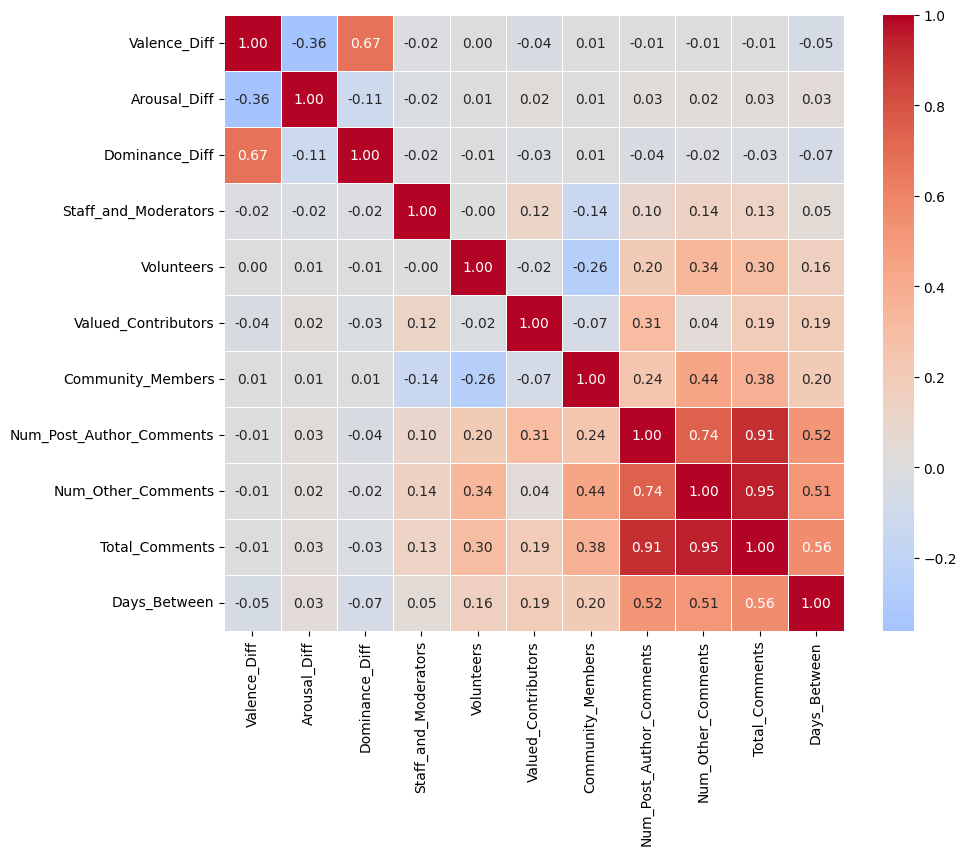

In [179]:
plt.figure(figsize=(10, 8))
corr = cause_mental_health_severity_table[['Valence_Diff', 'Arousal_Diff', 'Dominance_Diff', 'Staff_and_Moderators', 'Volunteers', 'Valued_Contributors', 'Community_Members', 'Num_Post_Author_Comments', 'Num_Other_Comments', 'Total_Comments', 'Days_Between']].corr()       # replace df with your dataset name

sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm", 
    center=0, 
    fmt=".2f",
    linewidths=0.5
)

# plt.title("Correlation Matrix")
plt.show()

In [246]:
comment_author_ranks = cause_mental_health_severity_table[['Post_ID','Volunteers', 'Staff_and_Moderators', 'Community_Members', 'Valued_Contributors']].copy()

In [271]:
# filter comment author ranks to only include rows where there are Beyond Blue Staff comments
comment_author_ranks_beyondblue = comment_author_ranks[(comment_author_ranks['Staff_and_Moderators'] == 0) & (comment_author_ranks['Community_Members'] == 1) & (comment_author_ranks['Volunteers'] == 0) & (comment_author_ranks['Valued_Contributors'] == 0) & (comment_author_ranks['Post_ID'].str[:4] == "Anxi")].copy()
comment_author_ranks_beyondblue[:5]

,Post_ID,Volunteers,Staff_and_Moderators,Community_Members,Valued_Contributors
2,Anxi-13,0,0,1,0
14,Anxi-69,0,0,1,0
17,Anxi-73,0,0,1,0
38,Anxi-119,0,0,1,0
40,Anxi-127,0,0,1,0


In [272]:
vad_table[vad_table['Post_ID'].str.contains("PTSD")]

,Post_ID,Author,Author_Post,Author_Last_Comment,Num_Post_Author_Comments,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,...,Days_Between,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance,Valence_Diff,Arousal_Diff,Dominance_Diff
6835,PTSD-1,Chriss,"cPTSD and anxiety. Hi, I'm struggling with cPT...","Hi Croix, Thank you for your words of support....",1,0,0,0,1,1,...,1,0.087256,0.002581,-0.005593,0.207375,-0.102675,0.042650,0.120119,-0.105256,0.048243
6836,PTSD-2,Rach28,Birthday card from abusive family. Hi everyone...,I threw the card out. I didn't want to keep it...,2,0,0,0,1,0,...,0,0.113043,0.000739,0.069054,0.130238,-0.022571,0.023286,0.017195,-0.023311,-0.045769
6837,PTSD-4,ScooterCat,Struggling to move on.(Safe: in my room listen...,Thanks to anyone who reads this. I might not h...,1,0,0,0,0,0,...,0,0.083486,-0.027220,-0.007899,0.233267,-0.006867,0.248600,0.149781,0.020354,0.256499
6838,PTSD-5,DarkQu,I don't know what's wrong with me. I don't kno...,‍I don't know what is wrong with me as a teena...,1,0,0,0,2,0,...,0,0.085225,-0.032056,0.005577,0.000027,-0.012387,-0.011427,-0.085199,0.019670,-0.017004
6839,PTSD-6,WishyBee,When you can’t avoid your triggers. I know tha...,Thanks for your reply white knight. I have avo...,1,0,0,0,1,0,...,3,0.062812,-0.088229,0.044500,0.230971,-0.063371,0.101200,0.168159,0.024858,0.056700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7844,PTSD-2046,Guest_2350,"Lost. Hello, I am hoping to find some advise-I...","Hi Neil, thank you for your reply. I hope that...",15,0,3,10,0,2,...,14,0.046826,-0.047529,-0.001326,0.181289,-0.064692,0.077830,0.134463,-0.017163,0.079156
7845,PTSD-2047,Jilly,Confused and Uncertain. I have spent 5 and a b...,Neil when I was 13 my brother made an attempt ...,1,0,2,0,0,1,...,2,0.056483,-0.041139,0.014120,0.073715,-0.053664,0.019918,0.017233,-0.012525,0.005798
7846,PTSD-2050,Raven666,I feel a need to share my sexual assault story...,Hey Geoff. Yeah I know where your coming from ...,1,0,0,1,0,0,...,0,0.077767,-0.007973,0.042361,0.052115,-0.027050,0.026975,-0.025652,-0.019077,-0.015386
7847,PTSD-2055,Lace,Trying to deal with the aftermath of appearing...,Thank you Neil for your reply. I wouldn't say ...,2,0,0,1,0,1,...,7,0.069041,-0.034831,0.012369,0.108046,-0.094800,0.016594,0.039005,-0.059969,0.004225


#### OLS

In [209]:
predictors = 'Community_Members + Staff_and_Moderators + Volunteers + Valued_Contributors + Days_Between'
# predictors = 'Community_Member + Beyond_Blue_Staff + Blue_Voices_Member + Community_Champion + Moderator + Valued_Contributor + Days_Between + Num_Post_Author_Comments'

##### Valence

In [210]:
formula_valence = ('Valence_Diff ~ ' + predictors)
model_valence = smf.ols(formula=formula_valence, data=cause_mental_health_severity_table).fit()
print(model_valence.summary())

                            OLS Regression Results                            
Dep. Variable:           Valence_Diff   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     7.719
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.97e-07
Time:                        19:06:45   Log-Likelihood:                 6048.4
No. Observations:                8385   AIC:                        -1.208e+04
Df Residuals:                    8379   BIC:                        -1.204e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0779 

In [211]:
cause_mental_health_severity_table_anxi = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Anxi')].copy()
cause_mental_health_severity_table_anxi = cause_mental_health_severity_table_anxi.dropna()

model_valence_anxi = smf.ols(formula=formula_valence, data=cause_mental_health_severity_table_anxi).fit()
print(model_valence_anxi.summary())


                            OLS Regression Results                            
Dep. Variable:           Valence_Diff   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.966
Date:                Tue, 25 Nov 2025   Prob (F-statistic):            0.00137
Time:                        19:06:45   Log-Likelihood:                 2720.6
No. Observations:                3648   AIC:                            -5429.
Df Residuals:                    3642   BIC:                            -5392.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0767 

In [212]:
cause_mental_health_severity_table_depr = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Depr')].copy()
cause_mental_health_severity_table_depr = cause_mental_health_severity_table_depr.dropna()

model_valence_depr = smf.ols(formula=formula_valence, data=cause_mental_health_severity_table_depr).fit()
print(model_valence_depr.summary())

                            OLS Regression Results                            
Dep. Variable:           Valence_Diff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.785
Date:                Tue, 25 Nov 2025   Prob (F-statistic):             0.0163
Time:                        19:06:45   Log-Likelihood:                 2364.9
No. Observations:                3185   AIC:                            -4718.
Df Residuals:                    3179   BIC:                            -4681.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0749 

In [213]:
cause_mental_health_severity_table_ptsd = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('PTSD')].copy()
cause_mental_health_severity_table_ptsd = cause_mental_health_severity_table_ptsd.dropna()

model_valence_ptsd = smf.ols(formula=formula_valence, data=cause_mental_health_severity_table_ptsd).fit()
print(model_valence_ptsd.summary())

                            OLS Regression Results                            
Dep. Variable:           Valence_Diff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8383
Date:                Tue, 25 Nov 2025   Prob (F-statistic):              0.523
Time:                        19:06:45   Log-Likelihood:                 662.86
No. Observations:                1014   AIC:                            -1314.
Df Residuals:                    1008   BIC:                            -1284.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0775 

In [214]:
cause_mental_health_severity_table_suic = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Suic')].copy()
cause_mental_health_severity_table_suic = cause_mental_health_severity_table_suic.dropna()

model_valence_suic = smf.ols(formula=formula_valence, data=cause_mental_health_severity_table_suic).fit()
print(model_valence_suic.summary())


                            OLS Regression Results                            
Dep. Variable:           Valence_Diff   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.911
Date:                Tue, 25 Nov 2025   Prob (F-statistic):            0.00172
Time:                        19:06:45   Log-Likelihood:                 336.59
No. Observations:                 538   AIC:                            -661.2
Df Residuals:                     532   BIC:                            -635.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0862 

##### Arousal

In [215]:
formula_arousal = ('Arousal_Diff ~ ' + predictors)
model_arousal = smf.ols(formula=formula_arousal, data=cause_mental_health_severity_table).fit()
print(model_arousal.summary())

                            OLS Regression Results                            
Dep. Variable:           Arousal_Diff   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.587
Date:                Tue, 25 Nov 2025   Prob (F-statistic):            0.00305
Time:                        19:06:45   Log-Likelihood:                 10675.
No. Observations:                8385   AIC:                        -2.134e+04
Df Residuals:                    8379   BIC:                        -2.129e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0262 

In [216]:
model_arousal_anxiety = smf.ols(formula=formula_arousal, data=cause_mental_health_severity_table_anxi).fit()
print(model_arousal_anxiety.summary())

                            OLS Regression Results                            
Dep. Variable:           Arousal_Diff   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.413
Date:                Tue, 25 Nov 2025   Prob (F-statistic):             0.0341
Time:                        19:06:45   Log-Likelihood:                 4702.5
No. Observations:                3648   AIC:                            -9393.
Df Residuals:                    3642   BIC:                            -9356.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0322 

In [225]:
model_arousal_depr = smf.ols(formula=formula_arousal, data=cause_mental_health_severity_table_depr).fit()
print(model_arousal_depr.summary())


                            OLS Regression Results                            
Dep. Variable:           Arousal_Diff   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.289
Date:                Tue, 25 Nov 2025   Prob (F-statistic):              0.266
Time:                        19:08:11   Log-Likelihood:                 4076.1
No. Observations:                3185   AIC:                            -8140.
Df Residuals:                    3179   BIC:                            -8104.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0152 

In [218]:
model_arousal_ptsd = smf.ols(formula=formula_arousal, data=cause_mental_health_severity_table_ptsd).fit()
print(model_arousal_ptsd.summary())

                            OLS Regression Results                            
Dep. Variable:           Arousal_Diff   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3315
Date:                Tue, 25 Nov 2025   Prob (F-statistic):              0.894
Time:                        19:06:45   Log-Likelihood:                 1255.6
No. Observations:                1014   AIC:                            -2499.
Df Residuals:                    1008   BIC:                            -2470.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0356 

In [219]:
model_arousal_suic = smf.ols(formula=formula_arousal, data=cause_mental_health_severity_table_suic).fit()
print(model_arousal_suic.summary())

                            OLS Regression Results                            
Dep. Variable:           Arousal_Diff   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.627
Date:                Tue, 25 Nov 2025   Prob (F-statistic):              0.151
Time:                        19:06:45   Log-Likelihood:                 696.19
No. Observations:                 538   AIC:                            -1380.
Df Residuals:                     532   BIC:                            -1355.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0215 

##### Dominance

In [220]:
formula_dominance = ('Dominance_Diff ~ ' + predictors)
model_dominance = smf.ols(formula=formula_dominance, data=cause_mental_health_severity_table).fit()
print(model_dominance.summary())

                            OLS Regression Results                            
Dep. Variable:         Dominance_Diff   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.567
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           4.19e-08
Time:                        19:06:45   Log-Likelihood:                 9738.4
No. Observations:                8385   AIC:                        -1.946e+04
Df Residuals:                    8379   BIC:                        -1.942e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0401 

In [221]:
model_dominance_anxi = smf.ols(formula=formula_dominance, data=cause_mental_health_severity_table_anxi).fit()
print(model_dominance_anxi.summary())

                            OLS Regression Results                            
Dep. Variable:         Dominance_Diff   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.189
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           0.000849
Time:                        19:06:45   Log-Likelihood:                 4291.1
No. Observations:                3648   AIC:                            -8570.
Df Residuals:                    3642   BIC:                            -8533.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0401 

In [222]:
model_dominance_depr = smf.ols(formula=formula_dominance, data=cause_mental_health_severity_table_depr).fit()
print(model_dominance_depr.summary())

                            OLS Regression Results                            
Dep. Variable:         Dominance_Diff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.383
Date:                Tue, 25 Nov 2025   Prob (F-statistic):             0.0362
Time:                        19:06:45   Log-Likelihood:                 3705.6
No. Observations:                3185   AIC:                            -7399.
Df Residuals:                    3179   BIC:                            -7363.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0376 

In [223]:
model_dominance_ptsd = smf.ols(formula=formula_dominance, data=cause_mental_health_severity_table_ptsd).fit()
print(model_dominance_ptsd.summary())

                            OLS Regression Results                            
Dep. Variable:         Dominance_Diff   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.772
Date:                Tue, 25 Nov 2025   Prob (F-statistic):              0.116
Time:                        19:06:45   Log-Likelihood:                 1202.5
No. Observations:                1014   AIC:                            -2393.
Df Residuals:                    1008   BIC:                            -2364.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0361 

In [224]:
model_dominance_suic = smf.ols(formula=formula_dominance, data=cause_mental_health_severity_table_suic).fit()
print(model_dominance_suic.summary())

                            OLS Regression Results                            
Dep. Variable:         Dominance_Diff   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.157
Date:                Tue, 25 Nov 2025   Prob (F-statistic):            0.00808
Time:                        19:06:45   Log-Likelihood:                 569.22
No. Observations:                 538   AIC:                            -1126.
Df Residuals:                     532   BIC:                            -1101.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0492 

#### Diagnostics

###### VIF for Multicollinearity

In [580]:
X = cause_mental_health_severity_table[['Staff_and_Moderators', 'Volunteers', 'Community_Member',
                                        'Valued_Contributor', 'Days_Between',
                                        ]].dropna()

vif = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)


               Variable       VIF
0  Staff_and_Moderators  1.153021
1            Volunteers  2.534590
2      Community_Member  1.890529
3    Valued_Contributor  1.235551
4          Days_Between  3.634704


###### Pairwise Correlation

In [328]:
corr_matrix = cause_mental_health_severity_table[['Beyond_Blue_Staff', 'Blue_Voices_Member', 
                                        'Community_Champion', 'Moderator', 
                                        'Valued_Contributor',
                                        'Days_Between',
                                        'Community_Member']].corr(method='pearson')
corr_matrix

,Beyond_Blue_Staff,Blue_Voices_Member,Community_Champion,Moderator,Valued_Contributor,Days_Between,Community_Member
Beyond_Blue_Staff,1.000000,0.040996,0.012563,-0.011698,-0.006237,0.013864,0.027860
Blue_Voices_Member,0.040996,1.000000,-0.002310,-0.070588,-0.088628,0.207743,0.159261
Community_Champion,0.012563,-0.002310,1.000000,0.079347,0.013943,0.315911,-0.016443
Moderator,-0.011698,-0.070588,0.079347,1.000000,0.148022,0.077591,-0.053432
Valued_Contributor,-0.006237,-0.088628,0.013943,0.148022,1.000000,0.186669,-0.017642
Days_Between,0.013864,0.207743,0.315911,0.077591,0.186669,1.000000,0.337450
Community_Member,0.027860,0.159261,-0.016443,-0.053432,-0.017642,0.337450,1.000000


###### Residual Normality

Valence

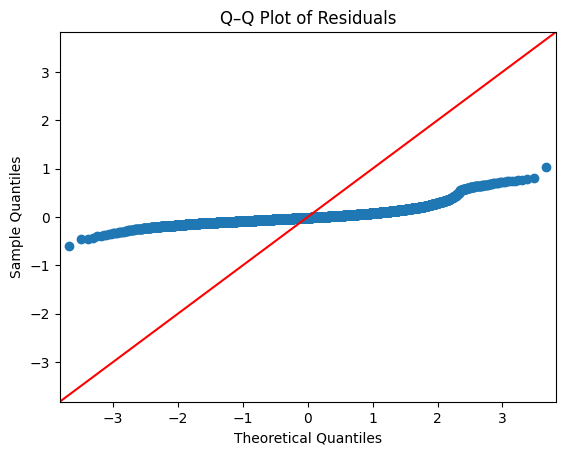

In [272]:
sm.qqplot(model_valence.resid, line='45')
plt.title("Q–Q Plot of Residuals")
plt.show()

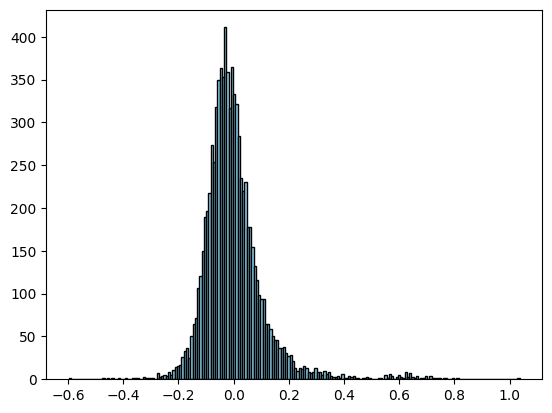

In [241]:
plt.hist(model_valence.resid, bins=200, color="skyblue", edgecolor="black")
plt.show()

Arousal

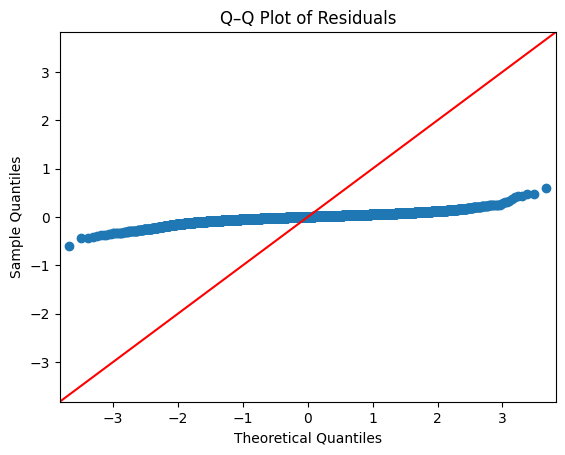

In [273]:
sm.qqplot(model_arousal.resid, line='45')
plt.title("Q–Q Plot of Residuals")
plt.show()

Dominance

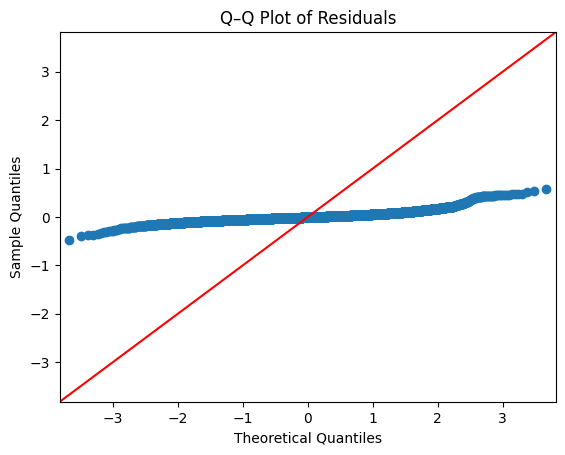

In [232]:
sm.qqplot(model_dominance.resid, line='45')
plt.title("Q–Q Plot of Residuals")
plt.show()

##### Heteroskedasticity

Valence

In [274]:
bp_test = het_breuschpagan(model_valence.resid, model_valence.model.exog)
print(f"Breusch–Pagan p-value: {bp_test[1]:.4f}")


Breusch–Pagan p-value: 0.0000


##### Fitted vs Residuals

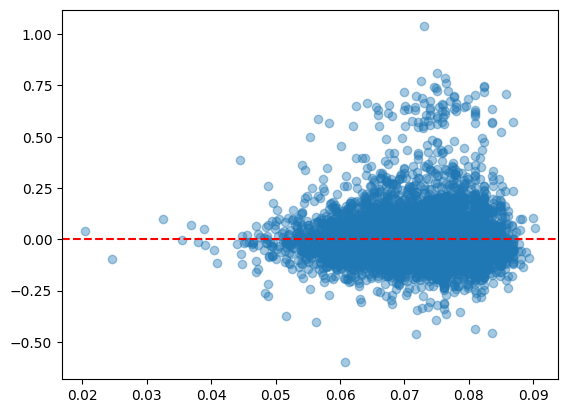

In [275]:
plt.scatter(model_valence.fittedvalues, model_valence.resid, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.show()

#### Multivariate Multiple Regression

In [153]:
corr = cause_mental_health_severity_table[['Valence_Diff', 'Arousal_Diff', 'Dominance_Diff']].corr()
print(corr)

                Valence_Diff  Arousal_Diff  Dominance_Diff
Valence_Diff        1.000000     -0.360969        0.670987
Arousal_Diff       -0.360969      1.000000       -0.106265
Dominance_Diff      0.670987     -0.106265        1.000000


##### Overall

##### Depression

In [160]:
cause_mental_health_severity_table_depr = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Depr')].copy()
model = MANOVA.from_formula('Valence_Diff + Arousal_Diff + Dominance_Diff ~ Staff_and_Moderators + Volunteers + Community_Members + Valued_Contributors + Days_Between', data=cause_mental_health_severity_table_depr)
print(model.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9417 3.0000 3177.0000 65.5994 0.0000
         Pillai's trace 0.0583 3.0000 3177.0000 65.5994 0.0000
 Hotelling-Lawley trace 0.0619 3.0000 3177.0000 65.5994 0.0000
    Roy's greatest root 0.0619 3.0000 3177.0000 65.5994 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
  Staff_and_Moderators  Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9960 3.0000 3177.0000  4.2268 0.0054
         Pillai's trace 0.0040 3.0000 3177.0000  4.2268 0.0054
 Hotelling-

##### Anxiety

In [165]:
cause_mental_health_severity_table_anxi = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Anxi')].copy()
model = MANOVA.from_formula('Valence_Diff + Arousal_Diff + Dominance_Diff ~ Staff_and_Moderators + Volunteers + Community_Members + Valued_Contributors + Days_Between', data=cause_mental_health_severity_table_anxi)
print(model.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9305 3.0000 3640.0000 90.6905 0.0000
         Pillai's trace 0.0695 3.0000 3640.0000 90.6905 0.0000
 Hotelling-Lawley trace 0.0747 3.0000 3640.0000 90.6905 0.0000
    Roy's greatest root 0.0747 3.0000 3640.0000 90.6905 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
  Staff_and_Moderators  Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9985 3.0000 3640.0000  1.8260 0.1402
         Pillai's trace 0.0015 3.0000 3640.0000  1.8260 0.1402
 Hotelling-

##### PTSD & Trauma

In [164]:
cause_mental_health_severity_table_ptsd = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('PTSD')].copy()
model = MANOVA.from_formula('Valence_Diff + Arousal_Diff + Dominance_Diff ~ Staff_and_Moderators + Volunteers + Community_Members + Valued_Contributors + Days_Between', data=cause_mental_health_severity_table_ptsd)
print(model.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9318 3.0000 1006.0000 24.5337 0.0000
         Pillai's trace 0.0682 3.0000 1006.0000 24.5337 0.0000
 Hotelling-Lawley trace 0.0732 3.0000 1006.0000 24.5337 0.0000
    Roy's greatest root 0.0732 3.0000 1006.0000 24.5337 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
  Staff_and_Moderators  Value  Num DF   Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9989 3.0000 1006.0000  0.3763 0.7701
         Pillai's trace 0.0011 3.0000 1006.0000  0.3763 0.7701
 Hotelling-

##### Suicidal Thoughts and Self-Harm

In [163]:
cause_mental_health_severity_table_suic = cause_mental_health_severity_table[cause_mental_health_severity_table['Post_ID'].str.startswith('Suic')].copy()
model = MANOVA.from_formula('Valence_Diff + Arousal_Diff + Dominance_Diff ~ Staff_and_Moderators + Volunteers + Community_Members + Valued_Contributors + Days_Between', data=cause_mental_health_severity_table_suic)
print(model.mv_test())

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9307 3.0000 530.0000 13.1507 0.0000
         Pillai's trace 0.0693 3.0000 530.0000 13.1507 0.0000
 Hotelling-Lawley trace 0.0744 3.0000 530.0000 13.1507 0.0000
    Roy's greatest root 0.0744 3.0000 530.0000 13.1507 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
  Staff_and_Moderators  Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9934 3.0000 530.0000  1.1789 0.3171
         Pillai's trace 0.0066 3.0000 530.0000  1.1789 0.3171
 Hotelling-Lawley trace 0.

# Testings

## Generate VAD Scores and Diffs

In [549]:
sample_mental_health_severity_table_1 = mental_health_severity_table.sample(50, random_state=42).copy()
# add VAD scores to mental_health_severity_table
sample_mental_health_severity_table_1[['Post_Valence', 'Post_Arousal', 'Post_Dominance']] = sample_mental_health_severity_table_1['Author_Post'].apply(lambda x: pd.Series(vad(x, polar_subset=True)))  
sample_mental_health_severity_table_1[['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']] = sample_mental_health_severity_table_1['Author_Last_Comment'].apply(lambda x: pd.Series(vad(x, polar_subset=True)))
# add VAD scores diff between post and comment
# sample_mental_health_severity_table['Valence_Diff'] = sample_mental_health_severity_table['Comment_Valence'] - sample_mental_health_severity_table['Post_Valence']
# sample_mental_health_severity_table['Arousal_Diff'] = sample_mental_health_severity_table['Comment_Arousal'] - sample_mental_health_severity_table['Post_Arousal']
# sample_mental_health_severity_table['Dominance_Diff'] = sample_mental_health_severity_table['Comment_Dominance'] - sample_mental_health_severity_table['Post_Dominance']
sample_mental_health_severity_table_1

,Post_ID,Author,Author_Post,Author_Last_Comment,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,Moderator,Valued Contributor,Days_Between,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance
3969,Depr-389,Richard,Teenage silence. Looking for advice for dealin...,Thankyou for your support and the fresh perspe...,0,0,0,0,0,0,1,7,0.421652,-0.186611,0.250824,0.514000,-0.132545,0.198143
6433,Depr-5359,Dalro45,Something wrong with my head. I know that I su...,lot I just re-read what I wrote and it makes n...,0,0,0,0,0,0,0,0,0.341195,-0.112896,0.070968,0.619667,-0.618500,-0.047500
6358,Depr-5225,Arbutus,Struggling. Here I go-my first post. I have be...,"Thank you all for your kind replies, and I apo...",0,0,2,0,1,0,0,5,0.252878,-0.168132,0.121038,0.213008,-0.114395,0.075488
221,Anxi-515,Harriolo,Overwhelmed with tasks. Does anyone else spend...,Thanks for your response. Nice to see that som...,0,0,0,1,1,0,0,4,0.364224,-0.069143,0.151333,0.605833,-0.010571,0.215833
8225,PTSD-2040,OUT_OF_FIGHT,New to Beyond Blue. I am a 58yr old woman with...,"Hi Neil, Thank you so much for your reply, I b...",0,0,0,0,1,0,0,1,0.127354,-0.127839,0.043524,0.161000,-0.197038,0.080339
3934,Depr-287,Supermum,Something needs to change. It is being a long ...,Thankyou to both of you for your replies and f...,0,0,0,0,1,0,2,4,0.136747,0.061923,0.116020,0.229152,-0.068206,0.224659
7171,PTSD-39,Rowen13,Unrequited friendships or low self-esteem?. Ho...,"Hi rx, I think the people we are drawn to, and...",0,0,0,0,4,0,21,26,0.339813,-0.090071,0.254957,0.311455,-0.094875,0.137371
5741,Depr-4187,OU812,"New Girlfriend depression, shuts down. Hi guys...",Thanks guys for the nice comments. I just feel...,0,1,1,0,0,0,0,0,0.299256,-0.035162,0.062818,0.379500,0.029167,0.282182
1374,Anxi-2907,Unsureonlife,"Quit job due to mental health-centreing. Hi, I...","Hi smallwolf, I recently had an and diagnosis ...",0,0,1,1,0,0,0,0,0.453286,0.071143,0.018846,0.366578,-0.060682,0.140250
7754,PTSD-1193,Guest5643,I Am a little on edge today. Hi I Am a little ...,Hi monkeymagic and islandwiz When I said swat ...,0,0,0,1,1,0,1,0,0.120179,-0.023310,-0.121783,0.385143,0.263375,0.235000


In [571]:
sample_mental_health_severity_table_2 = mental_health_severity_table.sample(50, random_state=42).copy()
# add VAD scores to mental_health_severity_table
sample_mental_health_severity_table_2[['Post_Valence', 'Post_Arousal', 'Post_Dominance']] = sample_mental_health_severity_table_2['Author_Post'].apply(lambda x: pd.Series(vad2(x, polar_subset=True)))  
sample_mental_health_severity_table_2[['Comment_Valence', 'Comment_Arousal', 'Comment_Dominance']] = sample_mental_health_severity_table_2['Author_Last_Comment'].apply(lambda x: pd.Series(vad2(x, polar_subset=True)))
# add VAD scores diff between post and comment
# sample_mental_health_severity_table['Valence_Diff'] = sample_mental_health_severity_table['Comment_Valence'] - sample_mental_health_severity_table['Post_Valence']
# sample_mental_health_severity_table['Arousal_Diff'] = sample_mental_health_severity_table['Comment_Arousal'] - sample_mental_health_severity_table['Post_Arousal']
# sample_mental_health_severity_table['Dominance_Diff'] = sample_mental_health_severity_table['Comment_Dominance'] - sample_mental_health_severity_table['Post_Dominance']
sample_mental_health_severity_table_2.head()

,Post_ID,Author,Author_Post,Author_Last_Comment,Beyond Blue Staff,Blue Voices Member,Champion Alumni,Community Champion,Community Member,Moderator,Valued Contributor,Days_Between,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance
3969,Depr-389,Richard,Teenage silence. Looking for advice for dealin...,Thankyou for your support and the fresh perspe...,0,0,0,0,0,0,1,7,0.421652,-0.186611,0.250824,0.514000,-0.132545,0.198143
6433,Depr-5359,Dalro45,Something wrong with my head. I know that I su...,lot I just re-read what I wrote and it makes n...,0,0,0,0,0,0,0,0,0.341195,-0.112896,0.070968,0.619667,-0.618500,-0.047500
6358,Depr-5225,Arbutus,Struggling. Here I go-my first post. I have be...,"Thank you all for your kind replies, and I apo...",0,0,2,0,1,0,0,5,0.252878,-0.168132,0.121038,0.213008,-0.114395,0.075488
221,Anxi-515,Harriolo,Overwhelmed with tasks. Does anyone else spend...,Thanks for your response. Nice to see that som...,0,0,0,1,1,0,0,4,0.364224,-0.069143,0.151333,0.605833,-0.010571,0.215833
8225,PTSD-2040,OUT_OF_FIGHT,New to Beyond Blue. I am a 58yr old woman with...,"Hi Neil, Thank you so much for your reply, I b...",0,0,0,0,1,0,0,1,0.127354,-0.127839,0.043524,0.161000,-0.197038,0.080339


In [553]:
float((sample_mental_health_severity_table_1.iloc[:,12:] == sample_mental_health_severity_table_2.iloc[:,12:]).values.sum()/(len(sample_mental_health_severity_table_1.iloc[:,12:].columns)*len(sample_mental_health_severity_table_1)))

0.99

In [554]:
sample_mental_health_severity_table_1.iloc[:,12:] == sample_mental_health_severity_table_2.iloc[:,12:]

,Post_Valence,Post_Arousal,Post_Dominance,Comment_Valence,Comment_Arousal,Comment_Dominance
3969,True,True,True,True,True,True
6433,True,True,True,True,True,True
6358,True,True,True,True,True,True
221,True,True,True,True,True,True
8225,True,True,True,True,True,True
3934,True,True,True,True,True,True
7171,True,True,True,True,True,True
5741,True,True,True,True,True,True
1374,True,True,True,True,True,True
7754,True,True,True,True,True,True


## Debugging difference between `vad()` and `vad2()`

In [566]:
sample_text = mental_health_severity_table.iloc[5067]['Author_Last_Comment']
sample_text

'Thank you for your response, I really just needed someone to respond and let me know that I am heard, so thank you.'

In [569]:
scores_1 = vad(sample_text, polar_subset=False)
print(scores_1)

{'valence': 0.2265, 'arousal': -0.1199375, 'dominance': 0.1289375}


In [570]:
scores_2 = vad2(sample_text, polar_subset=False)
print(scores_2)

{'valence': 0.2265, 'arousal': -0.1199375, 'dominance': 0.1289375}


## Polar Subsets

In [183]:
arousal_polar_from_vad = vad_lexicon[(vad_lexicon['dominance']<=-0.333) | (vad_lexicon['dominance']>=0.333)].copy()
arousal_polar_from_vad

,term,valence,arousal,dominance
10,a goner,-0.230,-0.148,-0.354
11,a good,0.666,-0.164,0.388
15,a little,0.072,-0.380,-0.358
27,a sec,-0.310,-0.234,-0.366
29,a single,-0.104,-0.126,-0.394
...,...,...,...,...
54786,zookeeper,0.296,0.625,0.519
54789,zoologist,0.778,0.458,0.667
54795,zoophobia,-0.833,-0.667,-0.630
54797,zorro,0.625,0.667,0.792


In [173]:
arousal_polar = pd.read_csv('./data/vad/valence-polar-NRC-VAD-Lexicon-v2.1.txt', delimiter='\t', header=0)
pd.unique(arousal_polar['valence'])

array([ 1.   ,  0.996,  0.994,  0.991,  0.99 ,  0.986,  0.985,  0.981,
        0.979,  0.976,  0.971,  0.968,  0.966,  0.963,  0.962,  0.96 ,
        0.958,  0.952,  0.949,  0.948,  0.945,  0.944,  0.942,  0.94 ,
        0.939,  0.938,  0.936,  0.934,  0.933,  0.932,  0.928,  0.927,
        0.926,  0.922,  0.92 ,  0.918,  0.917,  0.916,  0.912,  0.91 ,
        0.908,  0.906,  0.905,  0.904,  0.902,  0.9  ,  0.899,  0.898,
        0.896,  0.894,  0.893,  0.892,  0.891,  0.89 ,  0.889,  0.888,
        0.886,  0.884,  0.88 ,  0.878,  0.876,  0.875,  0.874,  0.873,
        0.872,  0.87 ,  0.868,  0.867,  0.866,  0.864,  0.862,  0.86 ,
        0.858,  0.857,  0.854,  0.852,  0.85 ,  0.846,  0.844,  0.84 ,
        0.838,  0.836,  0.834,  0.833,  0.832,  0.83 ,  0.828,  0.826,
        0.824,  0.822,  0.82 ,  0.818,  0.816,  0.815,  0.814,  0.812,
        0.81 ,  0.809,  0.808,  0.806,  0.804,  0.802,  0.8  ,  0.798,
        0.796,  0.794,  0.792,  0.79 ,  0.788,  0.786,  0.784,  0.78 ,
      

In [167]:
set(arousal_polar['term']) - set(arousal_polar_from_vad['term'])

{'addressbook',
 'alarm clock',
 'babycarriage',
 'biggestfear',
 'cantbreathe',
 'doubleclick',
 'dryclean',
 'farmhouse',
 'fishinghook',
 'fishingpole',
 'fishtank',
 'freakingout',
 'fuckedoff',
 'fucksake',
 'fuckyeah',
 'growthefuckup',
 'hairdress',
 'hand grenade',
 'hangup',
 'happynewyear',
 'happyvalentinesday',
 'hateeveryone',
 'hateyou',
 'horsetrading',
 'ironingboard',
 'jet ski',
 'jump rope',
 'lazyday',
 'lifevest',
 'littlethings',
 'lovebite',
 'lovemylife',
 'luckygirl',
 'mailserver',
 'mindmap',
 'mixedemotions',
 nan,
 'newsweek',
 'nocomplaints',
 'nopoint',
 'nothappy',
 'nowork',
 'oldfashioned',
 'oneday',
 'palmtree',
 'peaceofmind',
 'pencilsharpener',
 'pieceofshit',
 'roadsweeper',
 'rock band',
 'rollingpin',
 'safetypin',
 'slot machine',
 'sohappy',
 'soslow',
 'spinningwheel',
 'stressfree',
 'stupidpeople',
 'subheader',
 'sweetwater',
 'taperecorder',
 'tearsofjoy',
 'thankyou',
 'thelittlethings',
 'tiredofit',
 'toomuchtodo',
 'traindriver',
 'u

## N-gram positions

In [177]:
name_grams_positions = list(ngrams(range(len(word_tokenize("How are you today?"))), 2))
name_grams_positions = [set(pos) for pos in name_grams_positions]
name_grams_positions

[{0, 1}, {1, 2}, {2, 3}, {3, 4}]